# لهجة · Lahja — Arabic Dialect Classifier
### Optimized Notebook — Proper DSP Feature Engineering

**Dialects:** Egyptian (EGY) · Levantine/Syrian (SYR) · Emirati/Gulf (UAE) · Moroccan (MOR)

**Key improvements over previous version:**
- CMVN normalization (removes speaker-level bias, keeps dialect-level pattern)
- Formant-proxy features via LPC (captures vowel space differences between dialects)
- Prosodic / rhythmic features (Moroccan vs Egyptian rhythm differ structurally)
- Temporal statistics beyond mean+std (skewness, kurtosis, percentiles)
- Voiced/unvoiced ratio and syllabic rate
- Feature importance visualization (shows which features actually discriminate dialects)
- Per-dialect feature distribution plots (proves features are distinguishable — required by spec)
- SVM as primary model (better than RF on this problem size), RF kept as alternative

In [ ]:
!pip install librosa seaborn joblib scikit-learn matplotlib soundfile datasets scipy -q
print('✅ All dependencies installed')

✅ All dependencies installed


## Step 1 — Download Dataset

In [ ]:
from datasets import load_dataset
import os, soundfile as sf

DIALECTS        = ["EGY", "SYR", "UAE", "MOR"]
MAX_PER_DIALECT = 800
SAVE_DIR        = "/content/drive/MyDrive/dataset"

dialect_map = {
    "EGY": "egyptian",
    "SYR": "levant",
    "UAE": "emarit",
    "MOR": "moroccan",
}

ds = load_dataset(
    "ArabicSpeech/ADI17",
    split="dev",
    streaming=True
).shuffle(seed=42, buffer_size=3000)

counts = {d: 0 for d in DIALECTS}

for sample in ds:
    dialect_code = sample["dialect"]
    if dialect_code not in DIALECTS:
        continue
    if counts[dialect_code] >= MAX_PER_DIALECT:
        continue
    folder = os.path.join(SAVE_DIR, dialect_map[dialect_code])
    os.makedirs(folder, exist_ok=True)
    fname = f"{dialect_code}_{counts[dialect_code]+1:03d}.wav"
    sf.write(os.path.join(folder, fname),
             sample["audio"]["array"],
             sample["audio"]["sampling_rate"])
    counts[dialect_code] += 1
    if sum(counts.values()) % 100 == 0:
        print(f"  {counts}")
    if all(v >= MAX_PER_DIALECT for v in counts.values()):
        break

print("\n" + "="*45)
for code, name in dialect_map.items():
    status = "✅" if counts[code] == MAX_PER_DIALECT else f"⚠️  missing {MAX_PER_DIALECT - counts[code]}"
    print(f"  {name:12s} → {counts[code]:4d} files  {status}")
print("="*45)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Resolving data files:   0%|          | 0/40 [00:00<?, ?it/s]

  {'EGY': 0, 'SYR': 33, 'UAE': 67, 'MOR': 0}
  {'EGY': 0, 'SYR': 66, 'UAE': 134, 'MOR': 0}
  {'EGY': 0, 'SYR': 96, 'UAE': 204, 'MOR': 0}
  {'EGY': 0, 'SYR': 124, 'UAE': 276, 'MOR': 0}
  {'EGY': 0, 'SYR': 149, 'UAE': 351, 'MOR': 0}
  {'EGY': 0, 'SYR': 173, 'UAE': 427, 'MOR': 0}
  {'EGY': 0, 'SYR': 202, 'UAE': 498, 'MOR': 0}
  {'EGY': 0, 'SYR': 229, 'UAE': 559, 'MOR': 12}
  {'EGY': 0, 'SYR': 242, 'UAE': 613, 'MOR': 45}
  {'EGY': 0, 'SYR': 262, 'UAE': 657, 'MOR': 81}
  {'EGY': 0, 'SYR': 283, 'UAE': 703, 'MOR': 114}
  {'EGY': 2, 'SYR': 294, 'UAE': 759, 'MOR': 145}
  {'EGY': 32, 'SYR': 304, 'UAE': 794, 'MOR': 170}
  {'EGY': 90, 'SYR': 314, 'UAE': 800, 'MOR': 196}
  {'EGY': 151, 'SYR': 332, 'UAE': 800, 'MOR': 217}
  {'EGY': 220, 'SYR': 343, 'UAE': 800, 'MOR': 237}
  {'EGY': 280, 'SYR': 360, 'UAE': 800, 'MOR': 260}
  {'EGY': 350, 'SYR': 373, 'UAE': 800, 'MOR': 277}
  {'EGY': 409, 'SYR': 393, 'UAE': 800, 'MOR': 298}
  {'EGY': 469, 'SYR': 410, 'UAE': 800, 'MOR': 321}
  {'EGY': 537, 'SYR': 423, 

In [ ]:
from google.colab import files
import shutil

# This zips the entire 'dataset' folder from your Drive
shutil.make_archive('my_dialects_backup', 'zip', '/content/drive/MyDrive/dataset')

# This triggers the browser download
files.download('my_dialects_backup.zip')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


[egyptian] extracting 650 files...


egyptian: 100%|█████████████████████| 650/650 [05:34<00:00,  1.94it/s]


  ✅ 650 files averaged — F0=165.9 Hz, centroid=1576 Hz

[emarit] extracting 800 files...


emarit: 100%|███████████████████████| 800/800 [05:27<00:00,  2.44it/s]


  ✅ 800 files averaged — F0=195.8 Hz, centroid=1834 Hz

[levant] extracting 446 files...


levant: 100%|███████████████████████| 446/446 [03:20<00:00,  2.23it/s]


  ✅ 446 files averaged — F0=187.6 Hz, centroid=1579 Hz

[moroccan] extracting 380 files...


moroccan: 100%|█████████████████████| 380/380 [03:19<00:00,  1.91it/s]


  ✅ 380 files averaged — F0=212.6 Hz, centroid=1790 Hz

✅ All dialects extracted and averaged


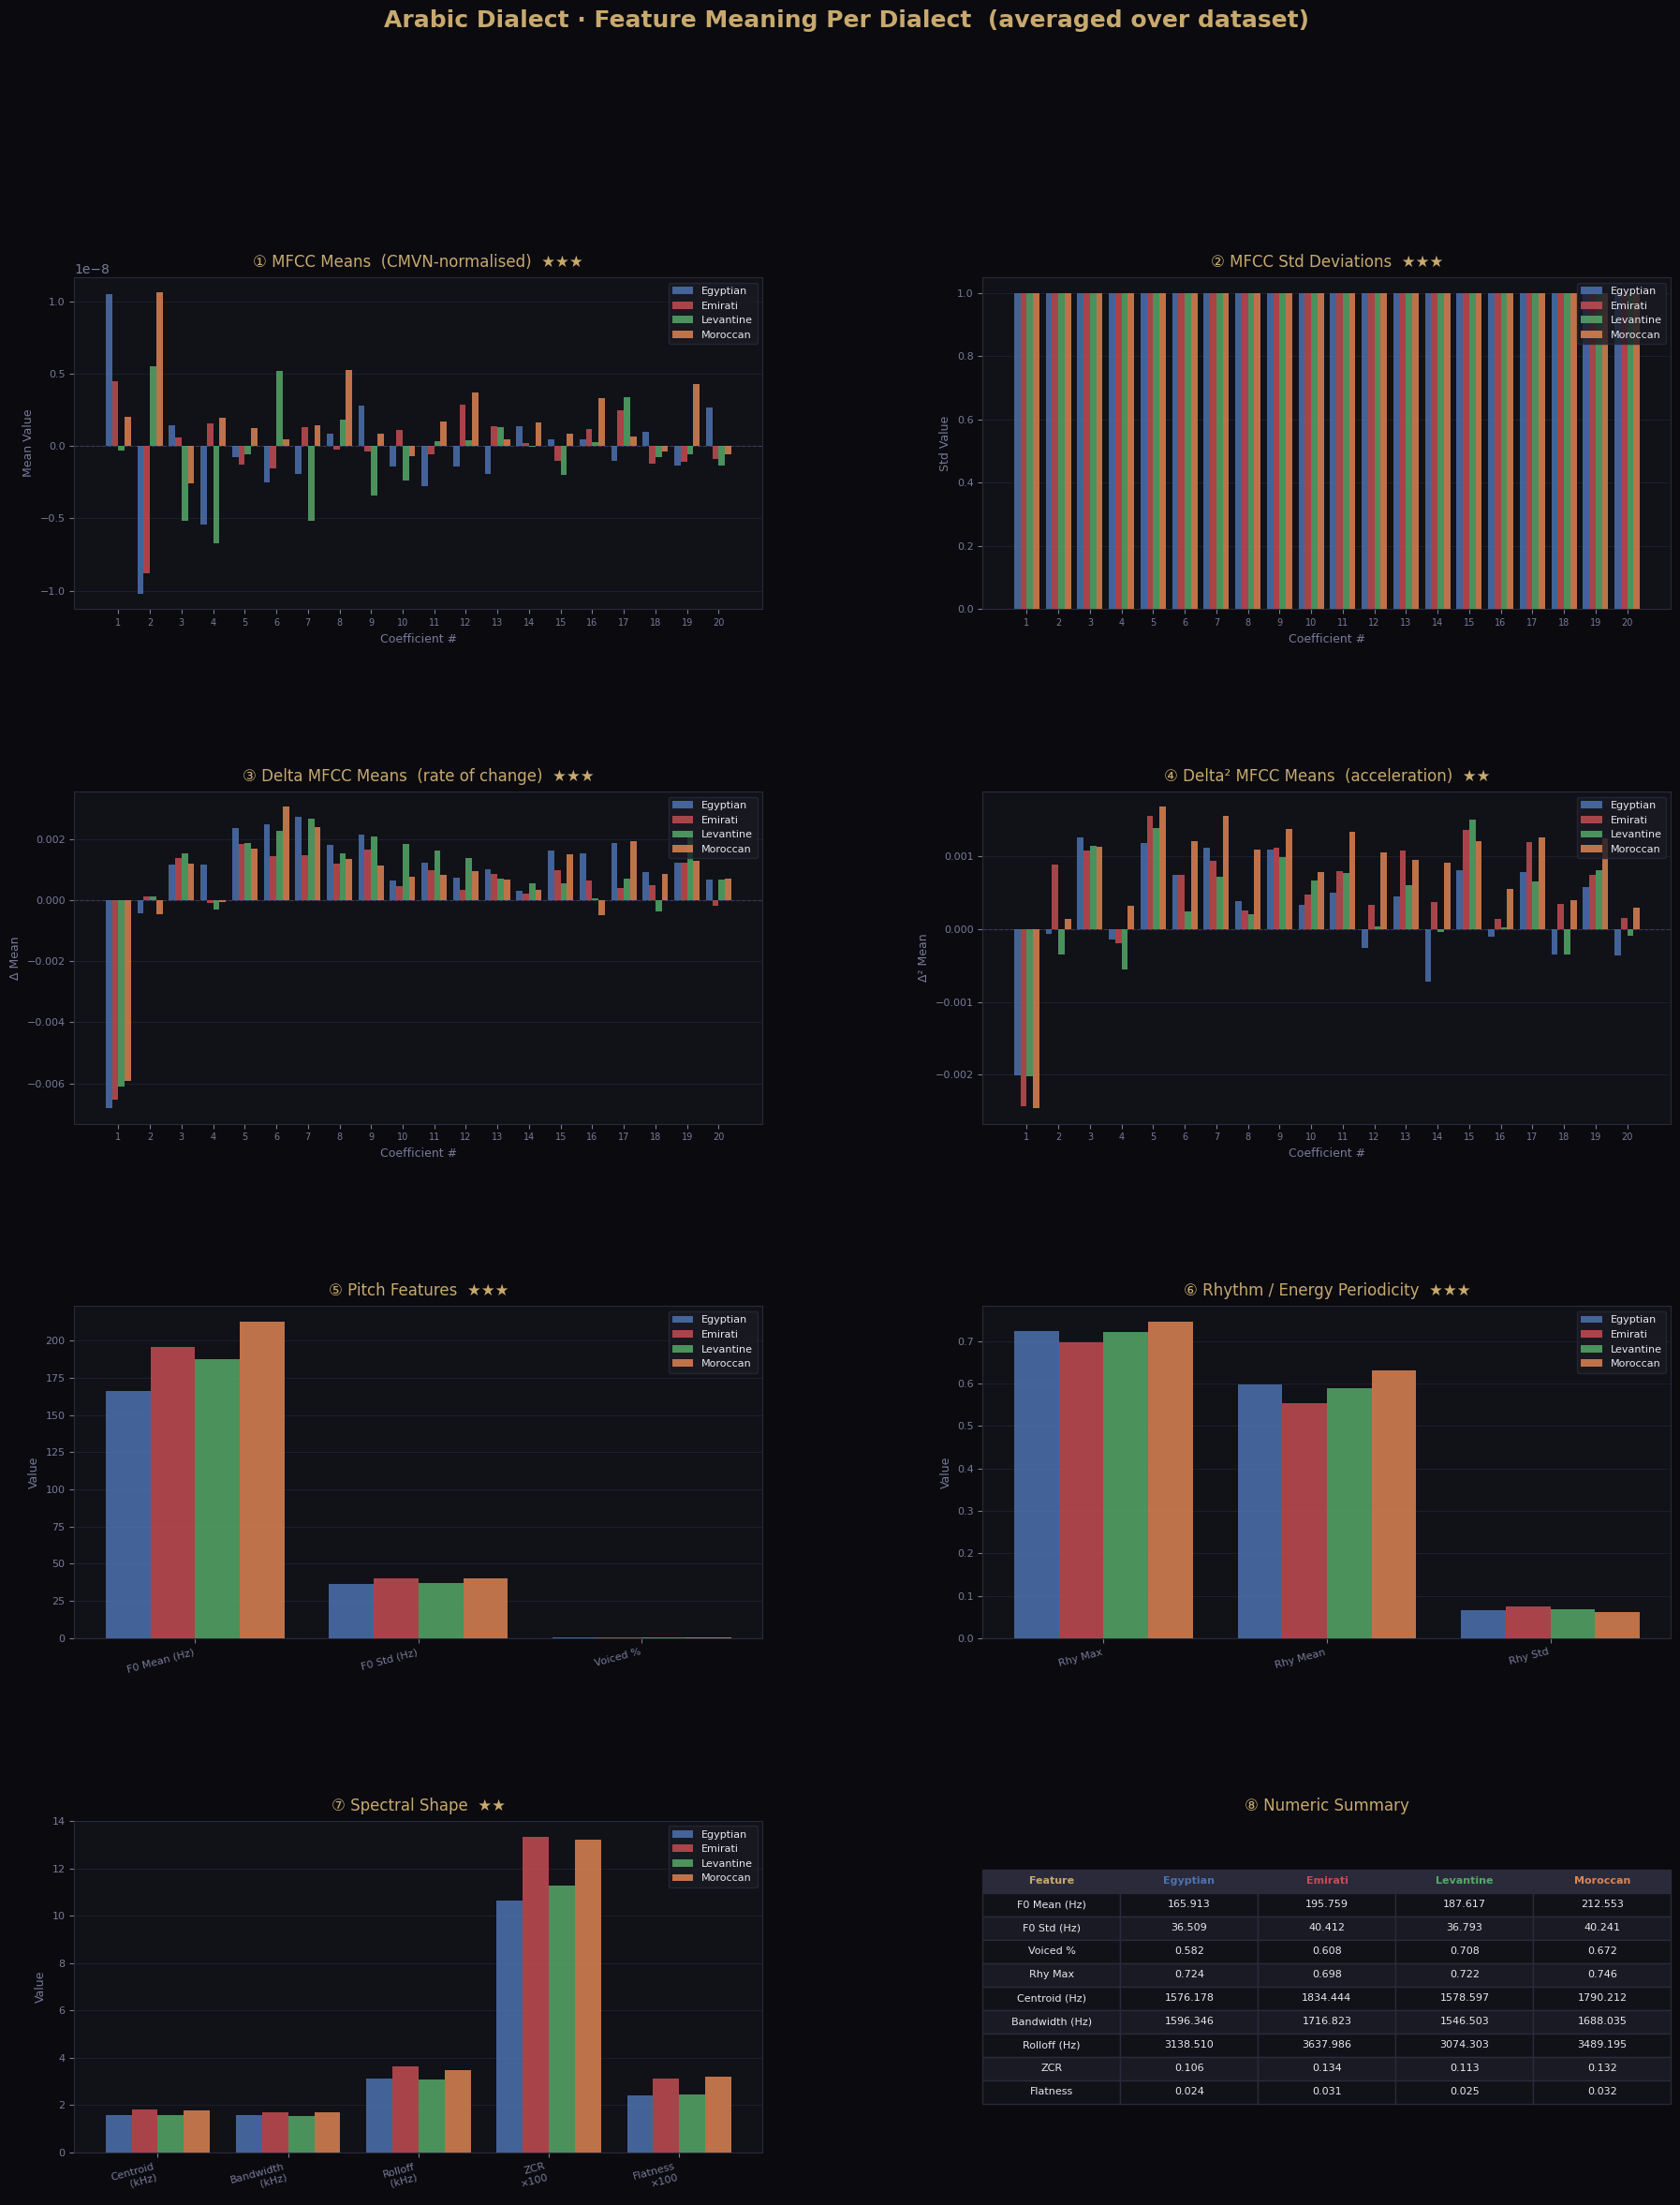

✅ Saved to Google Drive as dialect_feature_meaning.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FEATURE MEANING ANALYSIS — Average features per dialect
# ══════════════════════════════════════════════════════════════════

# ── Config (repeated so cell runs standalone) ─────────────────────
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
import warnings
warnings.filterwarnings("ignore")

DATASET_DIR     = "/content/drive/MyDrive/dataset"
SAMPLE_RATE     = 16_000
N_MFCC          = 20
N_LPC           = 12

DIALECT_FOLDERS = ["egyptian", "emarit", "levant", "moroccan"]
DIALECT_NAMES   = {
    "egyptian": "المصرية",
    "levant":   "الشامية",
    "emarit":   "الإماراتية",
    "moroccan": "المغربية",
}
COLORS = {
    "egyptian": "#4C72B0",
    "levant":   "#55A868",
    "emarit":   "#C44E52",
    "moroccan": "#DD8452",
}
LABELS = {
    "egyptian": "Egyptian",
    "levant":   "Levantine",
    "emarit":   "Emirati",
    "moroccan": "Moroccan",
}
# ─────────────────────────────────────────────────────────────────
from scipy.stats import skew, kurtosis
from tqdm import tqdm

SR     = 16_000
N_MFCC = 20
N_LPC  = 12

def extract_features_for_analysis(path):
    audio, sr = librosa.load(path, sr=SR, mono=True)
    if len(audio) < sr * 0.5:
        return None

    # ── MFCC (CMVN normalised) ──
    mfccs   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
    mu      = np.mean(mfccs, axis=1, keepdims=True)
    sig     = np.std( mfccs, axis=1, keepdims=True) + 1e-8
    mfccs_n = (mfccs - mu) / sig
    delta   = librosa.feature.delta(mfccs_n)
    delta2  = librosa.feature.delta(mfccs_n, order=2)

    # ── F0 / Pitch ──
    try:
        f0, voiced, _ = librosa.pyin(audio, fmin=70, fmax=400, sr=sr)
        voiced  = np.asarray(voiced, dtype=bool)
        f0v     = np.asarray(f0, dtype=float)[voiced]
        f0v     = f0v[~np.isnan(f0v)]
        f0_mean = float(np.mean(f0v)) if len(f0v) > 0 else 0.0
        f0_std  = float(np.std(f0v))  if len(f0v) > 0 else 0.0
        voiced_frac = float(np.mean(voiced))
    except:
        f0_mean = f0_std = voiced_frac = 0.0

    # ── Rhythm ──
    try:
        rms  = librosa.feature.rms(y=audio)[0]
        rms  = rms / (np.max(rms) + 1e-8)
        acf  = np.correlate(rms, rms, mode='full')
        half = len(acf) // 2
        acf  = acf[half:] / (acf[half] + 1e-8)
        lags = acf[10:51]
        rhy_max, rhy_mean, rhy_std = float(np.max(lags)), float(np.mean(lags)), float(np.std(lags))
    except:
        rhy_max = rhy_mean = rhy_std = 0.0

    # ── Spectral ──
    centroid  = float(np.mean(librosa.feature.spectral_centroid( y=audio, sr=sr)))
    bandwidth = float(np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr)))
    rolloff   = float(np.mean(librosa.feature.spectral_rolloff(  y=audio, sr=sr)))
    zcr       = float(np.mean(librosa.feature.zero_crossing_rate(audio)))
    flatness  = float(np.mean(librosa.feature.spectral_flatness( y=audio)))

    return {
        # per-coefficient arrays
        "mfcc_means":    np.mean(mfccs_n, axis=1),
        "mfcc_stds":     np.std( mfccs_n, axis=1),
        "delta_means":   np.mean(delta,   axis=1),
        "delta2_means":  np.mean(delta2,  axis=1),
        # scalars
        "f0_mean":       f0_mean,
        "f0_std":        f0_std,
        "voiced_frac":   voiced_frac,
        "rhy_max":       rhy_max,
        "rhy_mean":      rhy_mean,
        "rhy_std":       rhy_std,
        "centroid":      centroid,
        "bandwidth":     bandwidth,
        "rolloff":       rolloff,
        "zcr":           zcr,
        "flatness":      flatness,
    }

# ── Extract & average per dialect ────────────────────────────────
dialect_avgs = {}   # dialect → averaged feature dict

for dialect in DIALECT_FOLDERS:
    folder = os.path.join(DATASET_DIR, dialect)
    files  = [os.path.join(folder, f) for f in os.listdir(folder)
              if f.endswith(".wav")][:800]

    print(f"\n[{dialect}] extracting {len(files)} files...")
    all_feats = []
    for fpath in tqdm(files, desc=dialect, ncols=70):
        feats = extract_features_for_analysis(fpath)
        if feats is not None:
            all_feats.append(feats)

    # Average arrays and scalars separately
    avg = {}
    for k in ["mfcc_means","mfcc_stds","delta_means","delta2_means"]:
        avg[k] = np.mean([f[k] for f in all_feats], axis=0)
    for k in ["f0_mean","f0_std","voiced_frac","rhy_max","rhy_mean","rhy_std",
              "centroid","bandwidth","rolloff","zcr","flatness"]:
        avg[k] = float(np.mean([f[k] for f in all_feats]))

    dialect_avgs[dialect] = avg
    print(f"  ✅ {len(all_feats)} files averaged — F0={avg['f0_mean']:.1f} Hz, centroid={avg['centroid']:.0f} Hz")

print("\n✅ All dialects extracted and averaged")

# ══════════════════════════════════════════════════════════════════
#  PLOT
# ══════════════════════════════════════════════════════════════════
COLORS = {
    "egyptian": "#4C72B0",
    "levant":   "#55A868",
    "emarit":   "#C44E52",
    "moroccan": "#DD8452",
}
LABELS = {
    "egyptian": "Egyptian",
    "levant":   "Levantine",
    "emarit":   "Emirati",
    "moroccan": "Moroccan",
}

fig = plt.figure(figsize=(22, 26), facecolor='#0a0a0f')
fig.suptitle("Arabic Dialect · Feature Meaning Per Dialect  (averaged over dataset)",
             fontsize=18, color='#c8a96e', fontweight='bold', y=0.99)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.32)

dialects = list(dialect_avgs.keys())
colors   = [COLORS[d] for d in dialects]
labels   = [LABELS[d] for d in dialects]

# ── Helper: grouped bar (per-coefficient) ────────────────────────
def grouped_bar(ax, key, title, xlabel="Coefficient #", ylabel="Value"):
    ax.set_facecolor('#111118')
    ax.set_title(title, color='#c8a96e', fontsize=12, pad=8)
    ax.tick_params(colors='#7a7a9a', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#2a2a3a')
    ax.set_xlabel(xlabel, color='#7a7a9a', fontsize=9)
    ax.set_ylabel(ylabel, color='#7a7a9a', fontsize=9)
    ax.axhline(0, color='#3a3a5a', linewidth=0.8, linestyle='--')
    ax.grid(axis='y', color='#2a2a3a', linewidth=0.4)

    n     = len(dialect_avgs[dialects[0]][key])
    x     = np.arange(n)
    width = 0.8 / len(dialects)

    for j, (d, c, lbl) in enumerate(zip(dialects, colors, labels)):
        vals = dialect_avgs[d][key]
        ax.bar(x + j * width, vals, width=width, color=c,
               label=lbl, alpha=0.85, zorder=3)

    ax.set_xticks(x + width * (len(dialects) - 1) / 2)
    ax.set_xticklabels([str(i+1) for i in range(n)], fontsize=7)
    ax.legend(fontsize=8, facecolor='#1a1a24', labelcolor='#e8e8f0',
              edgecolor='#2a2a3a', loc='upper right')

# ── Helper: scalar grouped bar ───────────────────────────────────
def scalar_bar(ax, keys, display_keys, title, ylabel="Value"):
    ax.set_facecolor('#111118')
    ax.set_title(title, color='#c8a96e', fontsize=12, pad=8)
    ax.tick_params(colors='#7a7a9a', labelsize=8)
    for sp in ax.spines.values(): sp.set_edgecolor('#2a2a3a')
    ax.set_ylabel(ylabel, color='#7a7a9a', fontsize=9)
    ax.axhline(0, color='#3a3a5a', linewidth=0.8, linestyle='--')
    ax.grid(axis='y', color='#2a2a3a', linewidth=0.4)

    x     = np.arange(len(keys))
    width = 0.8 / len(dialects)

    for j, (d, c, lbl) in enumerate(zip(dialects, colors, labels)):
        vals = [dialect_avgs[d][k] for k in keys]
        ax.bar(x + j * width, vals, width=width, color=c,
               label=lbl, alpha=0.85, zorder=3)

    ax.set_xticks(x + width * (len(dialects) - 1) / 2)
    ax.set_xticklabels(display_keys, fontsize=8, rotation=15, ha='right')
    ax.legend(fontsize=8, facecolor='#1a1a24', labelcolor='#e8e8f0', edgecolor='#2a2a3a')

# ── Plot panels ──────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
grouped_bar(ax1, "mfcc_means", "① MFCC Means  (CMVN-normalised)  ★★★",
            ylabel="Mean Value")

ax2 = fig.add_subplot(gs[0, 1])
grouped_bar(ax2, "mfcc_stds", "② MFCC Std Deviations  ★★★",
            ylabel="Std Value")

ax3 = fig.add_subplot(gs[1, 0])
grouped_bar(ax3, "delta_means", "③ Delta MFCC Means  (rate of change)  ★★★",
            ylabel="Δ Mean")

ax4 = fig.add_subplot(gs[1, 1])
grouped_bar(ax4, "delta2_means", "④ Delta² MFCC Means  (acceleration)  ★★",
            ylabel="Δ² Mean")

ax5 = fig.add_subplot(gs[2, 0])
scalar_bar(ax5,
    ["f0_mean", "f0_std", "voiced_frac"],
    ["F0 Mean (Hz)", "F0 Std (Hz)", "Voiced %"],
    "⑤ Pitch Features  ★★★")

ax6 = fig.add_subplot(gs[2, 1])
scalar_bar(ax6,
    ["rhy_max", "rhy_mean", "rhy_std"],
    ["Rhy Max", "Rhy Mean", "Rhy Std"],
    "⑥ Rhythm / Energy Periodicity  ★★★")

ax7 = fig.add_subplot(gs[3, 0])
# Normalise to kHz / scaled for readability
for d in dialects:
    dialect_avgs[d]["centroid_kHz"]  = dialect_avgs[d]["centroid"]  / 1000
    dialect_avgs[d]["bandwidth_kHz"] = dialect_avgs[d]["bandwidth"] / 1000
    dialect_avgs[d]["rolloff_kHz"]   = dialect_avgs[d]["rolloff"]   / 1000
    dialect_avgs[d]["zcr_100"]       = dialect_avgs[d]["zcr"]       * 100
    dialect_avgs[d]["flat_100"]      = dialect_avgs[d]["flatness"]  * 100

scalar_bar(ax7,
    ["centroid_kHz","bandwidth_kHz","rolloff_kHz","zcr_100","flat_100"],
    ["Centroid\n(kHz)","Bandwidth\n(kHz)","Rolloff\n(kHz)","ZCR\n×100","Flatness\n×100"],
    "⑦ Spectral Shape  ★★")

# ── Numeric summary table ─────────────────────────────────────────
ax8 = fig.add_subplot(gs[3, 1])
ax8.set_facecolor('#111118')
ax8.axis('off')
ax8.set_title("⑧ Numeric Summary", color='#c8a96e', fontsize=12, pad=8)

row_labels = ["F0 Mean (Hz)","F0 Std (Hz)","Voiced %","Rhy Max",
              "Centroid (Hz)","Bandwidth (Hz)","Rolloff (Hz)","ZCR","Flatness"]
row_keys   = ["f0_mean","f0_std","voiced_frac","rhy_max",
              "centroid","bandwidth","rolloff","zcr","flatness"]

col_labels = ["Feature"] + [LABELS[d] for d in dialects]
table_data = []
for label, key in zip(row_labels, row_keys):
    row = [label] + [f"{dialect_avgs[d][key]:.3f}" for d in dialects]
    table_data.append(row)

tbl = ax8.table(cellText=table_data, colLabels=col_labels,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#2a2a3a')
    if r == 0:
        cell.set_facecolor('#2a2a3a')
        cell.set_text_props(color=colors[c-1] if c > 0 else '#c8a96e', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a24' if r % 2 == 0 else '#111118')
        cell.set_text_props(color='#e8e8f0')

plt.savefig("/content/drive/MyDrive/dialect_feature_meaning.png",
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved to Google Drive as dialect_feature_meaning.png")

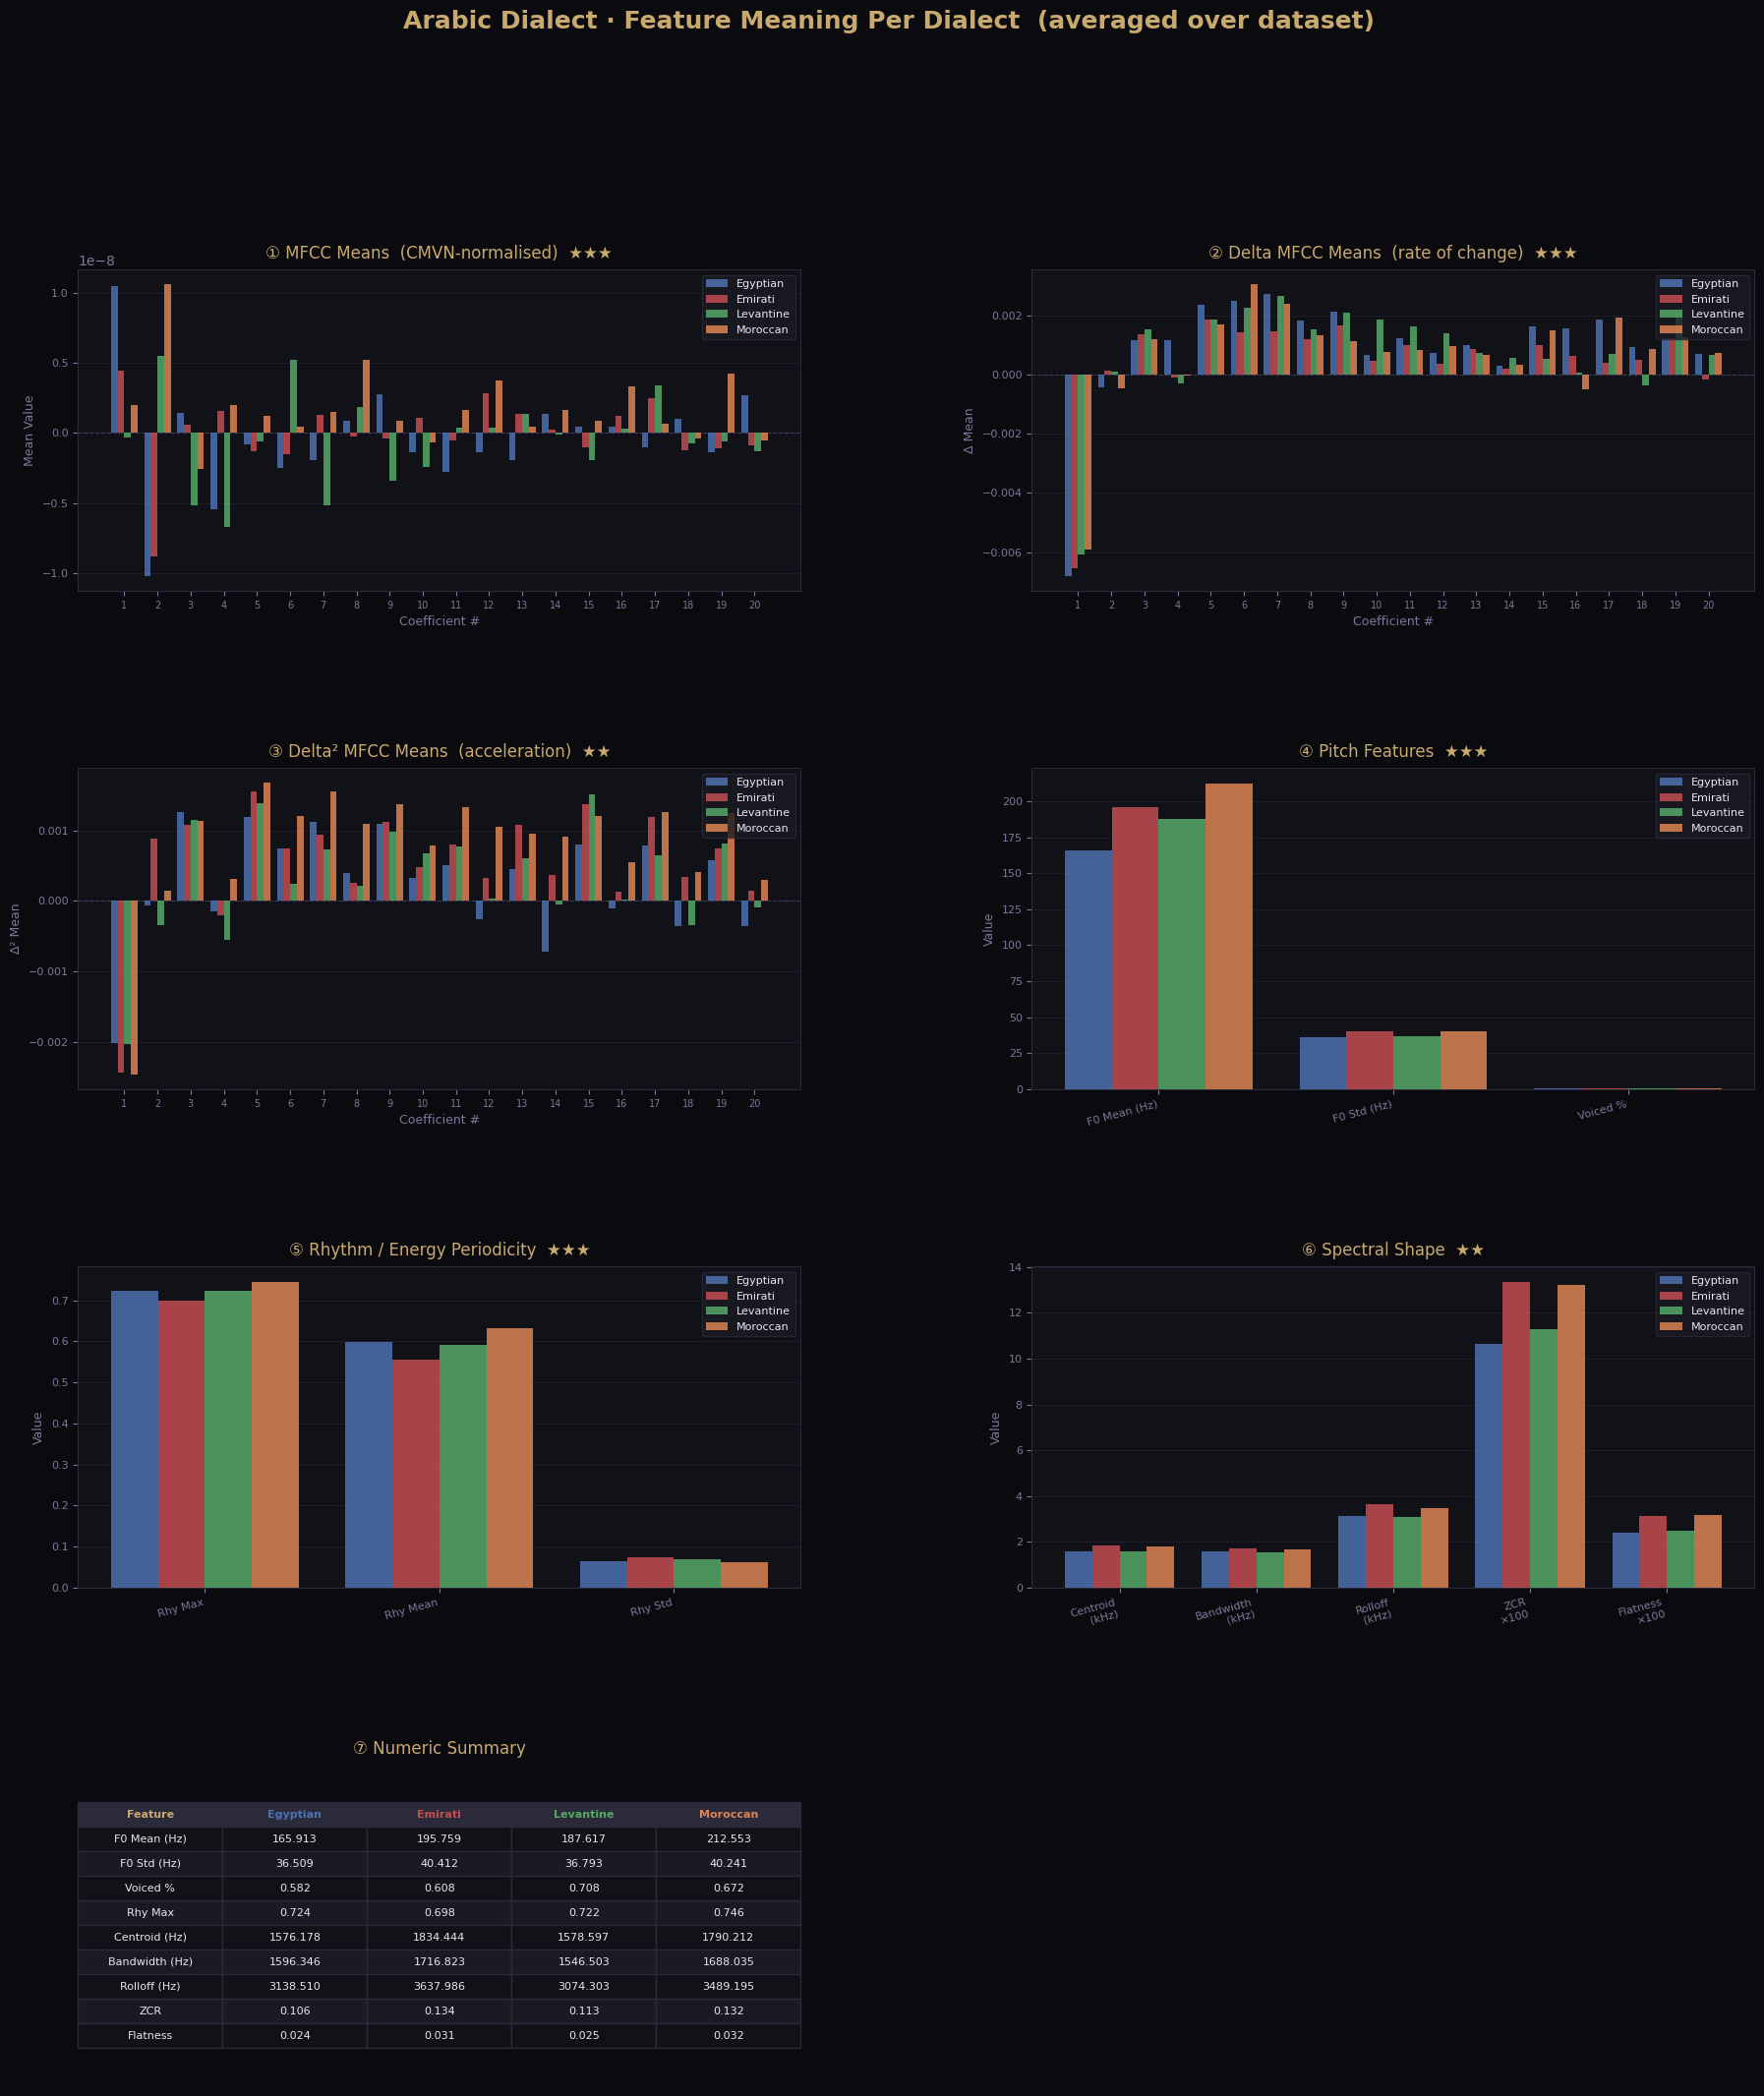

✅ Saved as dialect_feature_meaning_no_std.png


In [ ]:
# ══════════════════════════════════════════════════════════════════
#  REPLOT — All panels except MFCC Std Deviations
# ══════════════════════════════════════════════════════════════════

fig = plt.figure(figsize=(22, 24), facecolor='#0a0a0f')
fig.suptitle("Arabic Dialect · Feature Meaning Per Dialect  (averaged over dataset)",
             fontsize=18, color='#c8a96e', fontweight='bold', y=0.99)

gs = gridspec.GridSpec(4, 2, figure=fig, hspace=0.55, wspace=0.32)

dialects = list(dialect_avgs.keys())
colors   = [COLORS[d] for d in dialects]
labels   = [LABELS[d] for d in dialects]

# ── Panels ───────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0, 0])
grouped_bar(ax1, "mfcc_means", "① MFCC Means  (CMVN-normalised)  ★★★",
            ylabel="Mean Value")

ax2 = fig.add_subplot(gs[0, 1])
grouped_bar(ax2, "delta_means", "② Delta MFCC Means  (rate of change)  ★★★",
            ylabel="Δ Mean")

ax3 = fig.add_subplot(gs[1, 0])
grouped_bar(ax3, "delta2_means", "③ Delta² MFCC Means  (acceleration)  ★★",
            ylabel="Δ² Mean")

ax4 = fig.add_subplot(gs[1, 1])
scalar_bar(ax4,
    ["f0_mean", "f0_std", "voiced_frac"],
    ["F0 Mean (Hz)", "F0 Std (Hz)", "Voiced %"],
    "④ Pitch Features  ★★★")

ax5 = fig.add_subplot(gs[2, 0])
scalar_bar(ax5,
    ["rhy_max", "rhy_mean", "rhy_std"],
    ["Rhy Max", "Rhy Mean", "Rhy Std"],
    "⑤ Rhythm / Energy Periodicity  ★★★")

ax6 = fig.add_subplot(gs[2, 1])
scalar_bar(ax6,
    ["centroid_kHz","bandwidth_kHz","rolloff_kHz","zcr_100","flat_100"],
    ["Centroid\n(kHz)","Bandwidth\n(kHz)","Rolloff\n(kHz)","ZCR\n×100","Flatness\n×100"],
    "⑥ Spectral Shape  ★★")

# ── Numeric summary table ─────────────────────────────────────────
ax7 = fig.add_subplot(gs[3, 0])
ax7.set_facecolor('#111118')
ax7.axis('off')
ax7.set_title("⑦ Numeric Summary", color='#c8a96e', fontsize=12, pad=8)

row_labels = ["F0 Mean (Hz)","F0 Std (Hz)","Voiced %","Rhy Max",
              "Centroid (Hz)","Bandwidth (Hz)","Rolloff (Hz)","ZCR","Flatness"]
row_keys   = ["f0_mean","f0_std","voiced_frac","rhy_max",
              "centroid","bandwidth","rolloff","zcr","flatness"]

col_labels = ["Feature"] + [LABELS[d] for d in dialects]
table_data = []
for label, key in zip(row_labels, row_keys):
    row = [label] + [f"{dialect_avgs[d][key]:.3f}" for d in dialects]
    table_data.append(row)

tbl = ax7.table(cellText=table_data, colLabels=col_labels,
                loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(8)
tbl.scale(1, 1.5)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor('#2a2a3a')
    if r == 0:
        cell.set_facecolor('#2a2a3a')
        cell.set_text_props(color=colors[c-1] if c > 0 else '#c8a96e', fontweight='bold')
    else:
        cell.set_facecolor('#1a1a24' if r % 2 == 0 else '#111118')
        cell.set_text_props(color='#e8e8f0')

# ── Last cell empty (7 panels total, grid is 4×2=8) ──────────────
ax8 = fig.add_subplot(gs[3, 1])
ax8.set_facecolor('#111118')
ax8.axis('off')

plt.savefig("/content/drive/MyDrive/dialect_feature_meaning_no_std.png",
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved as dialect_feature_meaning_no_std.png")

Extracting features from all files...


egyptian: 100%|█████████████████████| 650/650 [05:39<00:00,  1.91it/s]


  ✅ 650 files — egyptian


emarit: 100%|███████████████████████| 800/800 [05:24<00:00,  2.46it/s]


  ✅ 800 files — emarit


levant: 100%|███████████████████████| 446/446 [03:18<00:00,  2.25it/s]


  ✅ 446 files — levant


moroccan: 100%|█████████████████████| 380/380 [03:18<00:00,  1.92it/s]


  ✅ 380 files — moroccan

Finding most discriminative features via ANOVA...

🏆 Top 6 most discriminative features:
  1. zcr                   F-score = 80.1
  2. centroid              F-score = 79.4
  3. rolloff               F-score = 69.6
  4. bandwidth             F-score = 54.5
  5. f0_mean               F-score = 44.0
  6. rhy_max               F-score = 20.6

Scoring files per dialect...
  ✅ egyptian: best scores = [np.float64(12.06), np.float64(12.04), np.float64(11.31), np.float64(10.45)]
  ✅ emarit: best scores = [np.float64(17.47), np.float64(14.85), np.float64(12.63), np.float64(12.61)]
  ✅ levant: best scores = [np.float64(12.59), np.float64(11.99), np.float64(10.76), np.float64(10.25)]
  ✅ moroccan: best scores = [np.float64(16.12), np.float64(13.96), np.float64(11.97), np.float64(11.67)]

  BEST FILES PER DIALECT

📁 Egyptian:
  #1  EGY_464.wav                     score=12.06  [zcr=0.076  |  centroid=953.916  |  rolloff=1553.902]
  #2  EGY_380.wav                     score

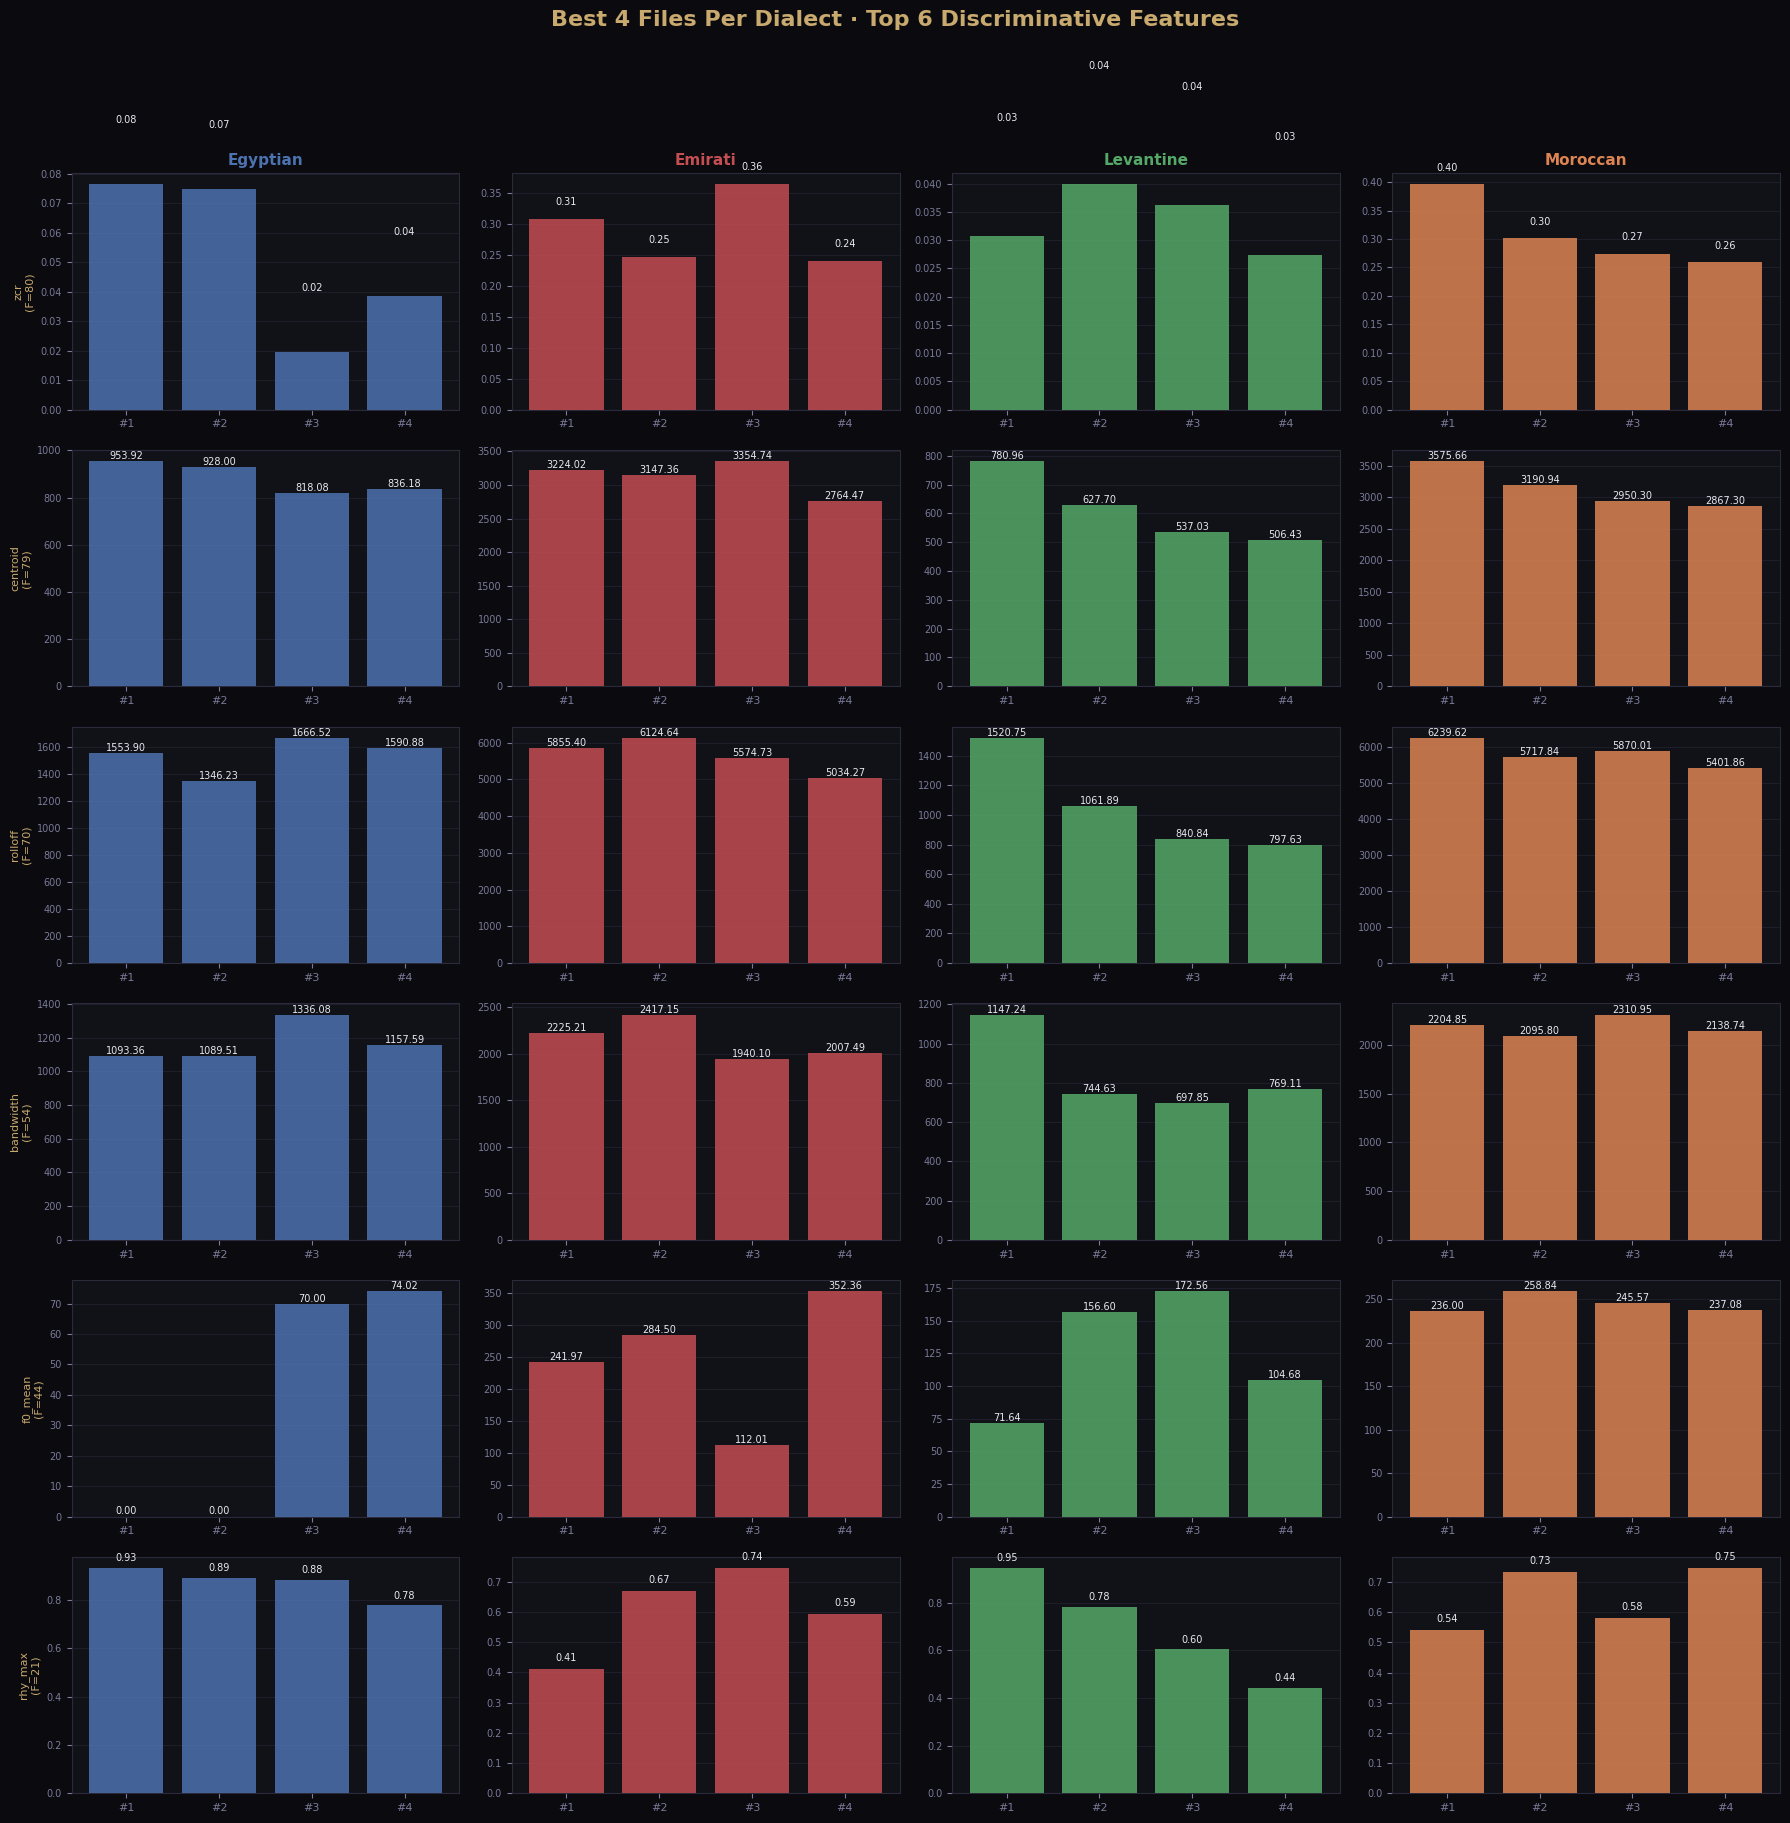

✅ Saved to Google Drive as best_4_files_per_dialect.png

  COPY THESE FILE PATHS FOR YOUR DEMO

Egyptian:
  1. /content/drive/MyDrive/dataset/egyptian/EGY_464.wav
  2. /content/drive/MyDrive/dataset/egyptian/EGY_380.wav
  3. /content/drive/MyDrive/dataset/egyptian/EGY_639.wav
  4. /content/drive/MyDrive/dataset/egyptian/EGY_511.wav

Emirati:
  1. /content/drive/MyDrive/dataset/emarit/UAE_287.wav
  2. /content/drive/MyDrive/dataset/emarit/UAE_249.wav
  3. /content/drive/MyDrive/dataset/emarit/UAE_767.wav
  4. /content/drive/MyDrive/dataset/emarit/UAE_658.wav

Levantine:
  1. /content/drive/MyDrive/dataset/levant/SYR_038.wav
  2. /content/drive/MyDrive/dataset/levant/SYR_406.wav
  3. /content/drive/MyDrive/dataset/levant/SYR_238.wav
  4. /content/drive/MyDrive/dataset/levant/SYR_003.wav

Moroccan:
  1. /content/drive/MyDrive/dataset/moroccan/MOR_214.wav
  2. /content/drive/MyDrive/dataset/moroccan/MOR_296.wav
  3. /content/drive/MyDrive/dataset/moroccan/MOR_255.wav
  4. /content/drive/My

In [ ]:
# ══════════════════════════════════════════════════════════════════
#  FIND BEST 4 FILES PER DIALECT — by most discriminative features
# ══════════════════════════════════════════════════════════════════

import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm import tqdm
from scipy.stats import f_oneway
import warnings
warnings.filterwarnings("ignore")

DATASET_DIR     = "/content/drive/MyDrive/dataset"
DIALECT_FOLDERS = ["egyptian", "emarit", "levant", "moroccan"]
LABELS = {"egyptian":"Egyptian","emarit":"Emirati","levant":"Levantine","moroccan":"Moroccan"}
COLORS = {"egyptian":"#4C72B0","emarit":"#C44E52","levant":"#55A868","moroccan":"#DD8452"}
SR     = 16_000
N_MFCC = 20
TOP_N_FILES     = 4     # best files per dialect
TOP_N_FEATURES  = 6     # how many discriminative features to score on

# ── Step 1: Extract all features from all files ───────────────────
def extract_all(path):
    try:
        audio, sr = librosa.load(path, sr=SR, mono=True)
        if len(audio) < sr * 0.5:
            return None
        mfccs   = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=N_MFCC)
        mu      = np.mean(mfccs, axis=1, keepdims=True)
        sig     = np.std( mfccs, axis=1, keepdims=True) + 1e-8
        mfccs_n = (mfccs - mu) / sig
        delta   = librosa.feature.delta(mfccs_n)

        try:
            f0, voiced, _ = librosa.pyin(audio, fmin=70, fmax=400, sr=sr)
            voiced = np.asarray(voiced, dtype=bool)
            f0v    = np.asarray(f0, dtype=float)[voiced]
            f0v    = f0v[~np.isnan(f0v)]
            f0_mean = float(np.mean(f0v)) if len(f0v) > 0 else 0.0
        except:
            f0_mean = 0.0

        try:
            rms  = librosa.feature.rms(y=audio)[0]
            rms  = rms / (np.max(rms) + 1e-8)
            acf  = np.correlate(rms, rms, mode='full')
            half = len(acf) // 2
            acf  = acf[half:] / (acf[half] + 1e-8)
            rhy_max = float(np.max(acf[10:51]))
        except:
            rhy_max = 0.0

        feats = {}
        for i in range(N_MFCC):
            feats[f"mfcc_{i+1}"]  = float(np.mean(mfccs_n[i, :]))
            feats[f"delta_{i+1}"] = float(np.mean(delta[i, :]))
        feats["f0_mean"]   = f0_mean
        feats["rhy_max"]   = rhy_max
        feats["centroid"]  = float(np.mean(librosa.feature.spectral_centroid( y=audio, sr=sr)))
        feats["bandwidth"] = float(np.mean(librosa.feature.spectral_bandwidth(y=audio, sr=sr)))
        feats["rolloff"]   = float(np.mean(librosa.feature.spectral_rolloff(  y=audio, sr=sr)))
        feats["zcr"]       = float(np.mean(librosa.feature.zero_crossing_rate(audio)))
        return feats
    except:
        return None

# collect all files + features per dialect
print("Extracting features from all files...")
dialect_data = {}   # dialect → list of (filepath, feature_dict)

for dialect in DIALECT_FOLDERS:
    folder = os.path.join(DATASET_DIR, dialect)
    files  = [os.path.join(folder, f) for f in sorted(os.listdir(folder))
              if f.endswith(".wav")][:800]
    results = []
    for fpath in tqdm(files, desc=dialect, ncols=70):
        feats = extract_all(fpath)
        if feats is not None:
            results.append((fpath, feats))
    dialect_data[dialect] = results
    print(f"  ✅ {len(results)} files — {dialect}")

# ── Step 2: Find most discriminative features via ANOVA ──────────
print("\nFinding most discriminative features via ANOVA...")

all_feature_keys = list(dialect_data[DIALECT_FOLDERS[0]][0][1].keys())
anova_scores = {}

for key in all_feature_keys:
    groups = []
    for dialect in DIALECT_FOLDERS:
        vals = [f[key] for _, f in dialect_data[dialect]]
        groups.append(vals)
    try:
        f_stat, p_val = f_oneway(*groups)
        anova_scores[key] = f_stat if not np.isnan(f_stat) else 0.0
    except:
        anova_scores[key] = 0.0

# Sort by F-statistic (higher = more discriminative)
sorted_feats = sorted(anova_scores.items(), key=lambda x: x[1], reverse=True)
top_features = [k for k, _ in sorted_feats[:TOP_N_FEATURES]]

print(f"\n🏆 Top {TOP_N_FEATURES} most discriminative features:")
for i, (k, score) in enumerate(sorted_feats[:TOP_N_FEATURES]):
    print(f"  {i+1}. {k:20s}  F-score = {score:.1f}")

# ── Step 3: Score each file — how "extreme" it is in top features ─
print("\nScoring files per dialect...")

# For each top feature, compute the mean across ALL dialects
global_means = {}
global_stds  = {}
for key in top_features:
    all_vals = [f[key] for dialect in DIALECT_FOLDERS for _, f in dialect_data[dialect]]
    global_means[key] = float(np.mean(all_vals))
    global_stds[key]  = float(np.std(all_vals)) + 1e-8

# For each dialect, score each file by how far it deviates
# from OTHER dialects' means in the top features
best_files = {}   # dialect → list of (score, filepath, feature_dict)

for dialect in DIALECT_FOLDERS:
    # compute this dialect's average per top feature
    dialect_feat_means = {}
    for key in top_features:
        dialect_feat_means[key] = float(np.mean(
            [f[key] for _, f in dialect_data[dialect]]
        ))

    scored = []
    for fpath, feats in dialect_data[dialect]:
        # score = sum of how close this file is to ITS dialect mean
        # (and how far from global mean) — picks "most representative" files
        score = 0.0
        for key in top_features:
            normalized_val  = (feats[key] - global_means[key]) / global_stds[key]
            dialect_norm    = (dialect_feat_means[key] - global_means[key]) / global_stds[key]
            # reward files whose feature aligns with dialect direction
            score += normalized_val * np.sign(dialect_norm)
        scored.append((score, fpath, feats))

    # sort by score descending — top 4 are most "dialect-typical"
    scored.sort(key=lambda x: x[0], reverse=True)
    best_files[dialect] = scored[:TOP_N_FILES]
    print(f"  ✅ {dialect}: best scores = {[round(s,2) for s,_,_ in best_files[dialect]]}")

# ── Step 4: Print best files ──────────────────────────────────────
print("\n" + "="*60)
print("  BEST FILES PER DIALECT")
print("="*60)
for dialect in DIALECT_FOLDERS:
    print(f"\n📁 {LABELS[dialect]}:")
    for rank, (score, fpath, feats) in enumerate(best_files[dialect], 1):
        fname = os.path.basename(fpath)
        feat_summary = "  |  ".join(
            [f"{k}={feats[k]:.3f}" for k in top_features[:3]]
        )
        print(f"  #{rank}  {fname:30s}  score={score:.2f}  [{feat_summary}]")

# ── Step 5: Plot comparison ───────────────────────────────────────
print("\nPlotting comparison...")

fig, axes = plt.subplots(
    len(top_features), len(DIALECT_FOLDERS),
    figsize=(18, 3 * len(top_features)),
    facecolor='#0a0a0f'
)
fig.suptitle(
    f"Best 4 Files Per Dialect · Top {TOP_N_FEATURES} Discriminative Features",
    fontsize=16, color='#c8a96e', fontweight='bold', y=1.01
)

for fi, feat_key in enumerate(top_features):
    f_score = anova_scores[feat_key]
    for di, dialect in enumerate(DIALECT_FOLDERS):
        ax = axes[fi][di]
        ax.set_facecolor('#111118')
        for sp in ax.spines.values(): sp.set_edgecolor('#2a2a3a')
        ax.tick_params(colors='#7a7a9a', labelsize=7)

        vals  = [feats[feat_key] for _, _, feats in best_files[dialect]]
        fnames = [os.path.basename(fp).replace('.wav','') for _, fp, _ in best_files[dialect]]
        color  = COLORS[dialect]

        bars = ax.bar(range(len(vals)), vals, color=color, alpha=0.85, zorder=3)
        ax.set_xticks(range(len(vals)))
        ax.set_xticklabels([f"#{i+1}" for i in range(len(vals))], fontsize=8)
        ax.axhline(0, color='#3a3a5a', linewidth=0.8, linestyle='--')
        ax.grid(axis='y', color='#2a2a3a', linewidth=0.4, zorder=0)

        # Add value labels on bars
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width()/2,
                    bar.get_height() + (0.02 if val >= 0 else -0.05),
                    f"{val:.2f}", ha='center', va='bottom',
                    fontsize=7, color='#e8e8f0')

        if fi == 0:
            ax.set_title(f"{LABELS[dialect]}", color=color,
                         fontsize=11, fontweight='bold', pad=6)
        if di == 0:
            ax.set_ylabel(f"{feat_key}\n(F={f_score:.0f})",
                          color='#c8a96e', fontsize=8)

plt.tight_layout()
plt.savefig("/content/drive/MyDrive/best_4_files_per_dialect.png",
            dpi=150, bbox_inches='tight', facecolor=fig.get_facecolor())
plt.show()
print("✅ Saved to Google Drive as best_4_files_per_dialect.png")

# ── Step 6: Save best file paths for easy reference ───────────────
print("\n" + "="*60)
print("  COPY THESE FILE PATHS FOR YOUR DEMO")
print("="*60)
for dialect in DIALECT_FOLDERS:
    print(f"\n{LABELS[dialect]}:")
    for rank, (score, fpath, _) in enumerate(best_files[dialect], 1):
        print(f"  {rank}. {fpath}")

## Step 2 — Config & Imports

In [ ]:
import os
import numpy as np
import librosa
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import joblib
import warnings
from scipy.signal import lfilter
from scipy.stats import skew, kurtosis
warnings.filterwarnings("ignore")

DATASET_DIR     = "/content/drive/MyDrive/dataset"
SAMPLE_RATE     = 16_000
N_MFCC          = 20          # increased from 13 — captures more spectral shape
N_LPC           = 12          # LPC order for formant-proxy features
MODEL_PATH      = "/content/drive/MyDrive/dialect_model.joblib"
ENCODER_PATH    = "/content/drive/MyDrive/label_encoder.joblib"
FEAT_NAMES_PATH = "/content/drive/MyDrive/feature_names.joblib"
FEAT_STATS_PATH = "/content/drive/MyDrive/feature_stats.joblib"

DIALECT_FOLDERS = ["egyptian", "emarit", "levant", "moroccan"]
DIALECT_NAMES   = {
    "egyptian": "المصرية",
    "levant":   "الشامية",
    "emarit":   "الإماراتية",
    "moroccan": "المغربية",
}
DIALECT_COLORS  = {
    "egyptian": "#4C72B0",
    "levant":   "#55A868",
    "emarit":   "#C44E52",
    "moroccan": "#DD8452",
}

print("✅ Config ready")
print(f"📁 Dataset dir  : {DATASET_DIR}")
print(f"🎚  N_MFCC       : {N_MFCC}")
print(f"🎚  N_LPC        : {N_LPC}")

✅ Config ready
📁 Dataset dir  : /content/drive/MyDrive/dataset
🎚  N_MFCC       : 20
🎚  N_LPC        : 12


In [ ]:
# ── Download best 4 files per dialect ────────────────────────────
from google.colab import files
import shutil, os

best_paths = {
    "Egyptian":  [
        "/content/drive/MyDrive/dataset/egyptian/EGY_464.wav",
        "/content/drive/MyDrive/dataset/egyptian/EGY_380.wav",
        "/content/drive/MyDrive/dataset/egyptian/EGY_639.wav",
        "/content/drive/MyDrive/dataset/egyptian/EGY_511.wav",
    ],
    "Emirati": [
        "/content/drive/MyDrive/dataset/emarit/UAE_287.wav",
        "/content/drive/MyDrive/dataset/emarit/UAE_249.wav",
        "/content/drive/MyDrive/dataset/emarit/UAE_767.wav",
        "/content/drive/MyDrive/dataset/emarit/UAE_658.wav",
    ],
    "Levantine": [
        "/content/drive/MyDrive/dataset/levant/SYR_038.wav",
        "/content/drive/MyDrive/dataset/levant/SYR_406.wav",
        "/content/drive/MyDrive/dataset/levant/SYR_238.wav",
        "/content/drive/MyDrive/dataset/levant/SYR_003.wav",
    ],
    "Moroccan": [
        "/content/drive/MyDrive/dataset/moroccan/MOR_214.wav",
        "/content/drive/MyDrive/dataset/moroccan/MOR_296.wav",
        "/content/drive/MyDrive/dataset/moroccan/MOR_255.wav",
        "/content/drive/MyDrive/dataset/moroccan/MOR_339.wav",
    ],
}

# Copy each file to /content with dialect prefix then download
for dialect, paths in best_paths.items():
    print(f"\n📥 Downloading {dialect}...")
    for rank, fpath in enumerate(paths, 1):
        fname    = os.path.basename(fpath)
        new_name = f"{dialect}_{rank}_{fname}"   # e.g. Egyptian_1_EGY_464.wav
        dest     = f"/content/{new_name}"
        shutil.copy(fpath, dest)
        files.download(dest)
        print(f"  ✅ {new_name}")

print("\n✅ All 16 files downloaded")


📥 Downloading Egyptian...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Egyptian_1_EGY_464.wav


<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

  ✅ Moroccan_3_MOR_255.wav


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

  ✅ Moroccan_4_MOR_339.wav

✅ All 16 files downloaded


## Step 3 — DSP Feature Extraction

### Why these features?

**CMVN (Cepstral Mean-Variance Normalization)**  
Raw MFCCs capture *who* is speaking (pitch, microphone, room). CMVN subtracts the per-file MFCC mean and divides by std, removing speaker and channel bias. What remains is the phoneme distribution — which is dialect-dependent.

**LPC coefficients (formant proxy)**  
Linear Predictive Coding models the vocal tract shape as an AR filter. The pole positions of this filter correspond to formant frequencies (F1, F2, F3). Arabic dialects differ in their vowel inventory — Egyptian /a/ vs Gulf /a/ vs Moroccan reduced vowels are distinguishable in the F1–F2 plane. We use LPC-12, giving 12 coefficients per frame.

**Prosodic / rhythmic features**  
Moroccan Darija is consonant-cluster-heavy with reduced vowels → low voiced fraction, spiky energy envelope.  
Egyptian is vowel-rich and metrically regular → higher voiced fraction, smoother energy.  
We capture: voiced fraction (from pyin), energy envelope autocorrelation (periodicity/rhythm), and speaking rate proxy (zero-crossing rate variance).

**Higher-order statistics (skewness, kurtosis)**  
Mean+std only captures the center and spread. Skewness tells us if the MFCC distribution leans left or right. Kurtosis tells us how peaky it is. Moroccan MFCCs are more negatively skewed than Egyptian because of consonant cluster dominance.

**Temporal percentiles**  
25th and 75th percentile of each MFCC over time captures sub-distribution shape without outlier sensitivity.

**Total feature vector: ~340 values** (fully documented below)

In [ ]:
def lpc_coefficients(audio, order=N_LPC):
    """
    Compute per-frame LPC coefficients via autocorrelation method.
    Returns array of shape (order, n_frames).
    These are formant proxies — the poles of the AR filter model the vocal tract.
    """
    frame_length = 512
    hop_length   = 256
    frames = librosa.util.frame(audio,
                                frame_length=frame_length,
                                hop_length=hop_length)
    # Apply Hamming window
    window = np.hamming(frame_length)
    frames = frames * window[:, np.newaxis]

    lpc_mat = []
    for i in range(frames.shape[1]):
        frame = frames[:, i]
        # Autocorrelation
        r = np.correlate(frame, frame, mode='full')
        r = r[len(r)//2 : len(r)//2 + order + 1]
        if r[0] < 1e-10:
            lpc_mat.append(np.zeros(order))
            continue
        # Levinson-Durbin (numpy lstsq — stable for small orders)
        R = np.array([[r[abs(i-j)] for j in range(order)] for i in range(order)])
        try:
            a = np.linalg.solve(R, r[1:order+1])
        except np.linalg.LinAlgError:
            a = np.zeros(order)
        lpc_mat.append(a)
    return np.array(lpc_mat).T   # shape: (order, n_frames)


def energy_envelope_periodicity(audio, sr, hop=256):
    """
    RMS energy envelope → autocorrelation at lag ~100-300ms.
    High periodicity = regular rhythm (Egyptian, Levantine).
    Low periodicity  = irregular/clustered rhythm (Moroccan).
    """
    rms = librosa.feature.rms(y=audio, hop_length=hop)[0]
    rms = rms / (np.max(rms) + 1e-8)  # normalize
    # Autocorrelation at lags 10-50 frames (~160ms-800ms at 16kHz, hop=256)
    acf = np.correlate(rms, rms, mode='full')
    acf = acf[len(acf)//2:]
    acf = acf / (acf[0] + 1e-8)
    lags = acf[10:51]  # 42 lag values
    return float(np.max(lags)), float(np.mean(lags)), float(np.std(lags))


def voiced_fraction(audio, sr):
    """
    Fraction of frames where voiced activity is detected via pyin.
    Egyptian/Levantine: vowel-heavy → higher voiced fraction.
    Moroccan: consonant-cluster-heavy → lower voiced fraction.
    """
    try:
        _, voiced_flag, _ = librosa.pyin(
            audio, fmin=70, fmax=400, sr=sr,
            frame_length=1024, hop_length=256
        )
        if voiced_flag is None or len(voiced_flag) == 0:
            return 0.5, 0.0, 0.0
        vf = float(np.mean(voiced_flag))
        # Also extract f0 stats on voiced frames
        f0, _, _ = librosa.pyin(audio, fmin=70, fmax=400, sr=sr,
                                 frame_length=1024, hop_length=256)
        f0_voiced = f0[voiced_flag] if voiced_flag is not None else np.array([])
        f0_voiced = f0_voiced[~np.isnan(f0_voiced)]
        f0_mean   = float(np.mean(f0_voiced))   if len(f0_voiced) > 0 else 0.0
        f0_std    = float(np.std(f0_voiced))    if len(f0_voiced) > 0 else 0.0
        return vf, f0_mean, f0_std
    except Exception:
        return 0.5, 0.0, 0.0


def extract_features(file_path, sr=SAMPLE_RATE, n_mfcc=N_MFCC, n_lpc=N_LPC):
    """
    Full DSP feature extraction pipeline.

    Feature groups and sizes:
    ─────────────────────────────────────────────────────────
    Group                         Features                  Count
    ─────────────────────────────────────────────────────────
    CMVN-normalized MFCC          mean, std                 2×20 = 40
    CMVN-normalized MFCC          p25, p75                  2×20 = 40
    CMVN-normalized MFCC          skewness, kurtosis        2×20 = 40
    Delta MFCC (CMVN)             mean, std                 2×20 = 40
    Delta² MFCC (CMVN)            mean, std                 2×20 = 40
    LPC coefficients              mean, std                 2×12 = 24
    Chroma (12 bins)              mean, std                 2×12 = 24
    Spectral contrast (7 bands)   mean, std                 2×7  = 14
    Spectral shape scalars        centroid,bandwidth,
                                  rolloff,flatness,ZCR      5×2  = 10  (mean+std each)
    Prosodic scalars              voiced_frac, f0_mean,
                                  f0_std, rhythm_max,
                                  rhythm_mean, rhythm_std   6 scalars
    ─────────────────────────────────────────────────────────
    TOTAL                                                    ~318
    ─────────────────────────────────────────────────────────
    """
    try:
        audio, _ = librosa.load(file_path, sr=sr, mono=True)
        if len(audio) < sr * 0.5:   # skip files shorter than 0.5s
            print(f"  [skip] too short: {file_path}")
            return None

        # ── 1. CMVN-normalized MFCCs ──────────────────────────
        mfccs  = librosa.feature.mfcc(y=audio, sr=sr, n_mfcc=n_mfcc)
        # CMVN: subtract per-utterance mean, divide by per-utterance std
        mfcc_mean_utt = np.mean(mfccs, axis=1, keepdims=True)
        mfcc_std_utt  = np.std(mfccs,  axis=1, keepdims=True) + 1e-8
        mfccs_norm    = (mfccs - mfcc_mean_utt) / mfcc_std_utt

        # Statistics over normalized frames
        mfcc_mean = np.mean(mfccs_norm, axis=1)           # (n_mfcc,)
        mfcc_std  = np.std( mfccs_norm, axis=1)           # (n_mfcc,)
        mfcc_p25  = np.percentile(mfccs_norm, 25, axis=1) # (n_mfcc,)
        mfcc_p75  = np.percentile(mfccs_norm, 75, axis=1) # (n_mfcc,)
        mfcc_skew = skew(mfccs_norm, axis=1)              # (n_mfcc,)
        mfcc_kurt = kurtosis(mfccs_norm, axis=1)          # (n_mfcc,)

        # ── 2. Delta & Delta² MFCCs (on CMVN-normalized) ─────
        delta   = librosa.feature.delta(mfccs_norm)
        delta2  = librosa.feature.delta(mfccs_norm, order=2)
        # Normalize deltas too
        d_std   = np.std(delta,  axis=1, keepdims=True)  + 1e-8
        d2_std  = np.std(delta2, axis=1, keepdims=True) + 1e-8
        delta_n  = delta  / d_std
        delta2_n = delta2 / d2_std

        delta_mean  = np.mean(delta_n,  axis=1)
        delta_std   = np.std( delta_n,  axis=1)
        delta2_mean = np.mean(delta2_n, axis=1)
        delta2_std  = np.std( delta2_n, axis=1)

        # ── 3. LPC coefficients (formant proxy) ───────────────
        lpc_mat  = lpc_coefficients(audio, order=n_lpc)   # (n_lpc, n_frames)
        lpc_mean = np.mean(lpc_mat, axis=1)               # (n_lpc,)
        lpc_std  = np.std( lpc_mat, axis=1)               # (n_lpc,)

        # ── 4. Chroma (tonal / vowel color) ───────────────────
        chroma      = librosa.feature.chroma_stft(y=audio, sr=sr)
        chroma_mean = np.mean(chroma, axis=1)             # (12,)
        chroma_std  = np.std( chroma, axis=1)             # (12,)

        # ── 5. Spectral contrast ──────────────────────────────
        contrast      = librosa.feature.spectral_contrast(y=audio, sr=sr)
        contrast_mean = np.mean(contrast, axis=1)         # (7,)
        contrast_std  = np.std( contrast, axis=1)         # (7,)

        # ── 6. Spectral shape scalars ─────────────────────────
        centroid  = librosa.feature.spectral_centroid( y=audio, sr=sr)[0]
        bandwidth = librosa.feature.spectral_bandwidth(y=audio, sr=sr)[0]
        rolloff   = librosa.feature.spectral_rolloff(  y=audio, sr=sr)[0]
        flatness  = librosa.feature.spectral_flatness( y=audio)[0]
        zcr       = librosa.feature.zero_crossing_rate(audio)[0]

        spectral_scalars = np.array([
            np.mean(centroid),  np.std(centroid),
            np.mean(bandwidth), np.std(bandwidth),
            np.mean(rolloff),   np.std(rolloff),
            np.mean(flatness),  np.std(flatness),
            np.mean(zcr),       np.std(zcr),
        ])

        # ── 7. Prosodic / rhythmic features ───────────────────
        vf, f0_mean, f0_std           = voiced_fraction(audio, sr)
        rhy_max, rhy_mean, rhy_std    = energy_envelope_periodicity(audio, sr)

        prosodic_scalars = np.array([vf, f0_mean, f0_std,
                                     rhy_max, rhy_mean, rhy_std])

        # ── Concatenate everything ─────────────────────────────
        vector = np.concatenate([
            mfcc_mean, mfcc_std,           # 40
            mfcc_p25,  mfcc_p75,           # 40
            mfcc_skew, mfcc_kurt,          # 40
            delta_mean, delta_std,         # 40
            delta2_mean, delta2_std,       # 40
            lpc_mean, lpc_std,             # 24
            chroma_mean, chroma_std,       # 24
            contrast_mean, contrast_std,   # 14
            spectral_scalars,              # 10
            prosodic_scalars,              # 6
        ])

        return vector.astype(np.float32)

    except Exception as e:
        print(f"  [error] {file_path}: {e}")
        return None


def build_feature_names(n_mfcc=N_MFCC, n_lpc=N_LPC):
    """Returns a list of human-readable names matching the feature vector order."""
    names = []
    for stat in ['mean','std','p25','p75','skew','kurt']:
        names += [f'mfcc_{i+1}_{stat}' for i in range(n_mfcc)]
    for stat in ['mean','std']:
        names += [f'delta_{i+1}_{stat}'  for i in range(n_mfcc)]
        names += [f'delta2_{i+1}_{stat}' for i in range(n_mfcc)]
    for stat in ['mean','std']:
        names += [f'lpc_{i+1}_{stat}' for i in range(n_lpc)]
    for stat in ['mean','std']:
        names += [f'chroma_{i+1}_{stat}' for i in range(12)]
    for stat in ['mean','std']:
        names += [f'contrast_{i+1}_{stat}' for i in range(7)]
    for feat in ['centroid','bandwidth','rolloff','flatness','zcr']:
        names += [f'{feat}_mean', f'{feat}_std']
    names += ['voiced_frac','f0_mean','f0_std','rhythm_max','rhythm_mean','rhythm_std']
    return names


FEATURE_NAMES = build_feature_names()
EXPECTED_SIZE = (6*N_MFCC) + (4*N_MFCC) + (2*N_LPC) + 24 + 14 + 10 + 6
print(f"✅ Feature extraction functions ready")
print(f"📐 Expected feature vector size: {EXPECTED_SIZE}")
print(f"📋 Feature names: {len(FEATURE_NAMES)} entries")
print()
print("Feature groups:")
groups = [
    ('CMVN MFCC (mean,std,p25,p75,skew,kurt)', 6*N_MFCC),
    ('Delta MFCC (mean,std)',  2*N_MFCC),
    ('Delta² MFCC (mean,std)', 2*N_MFCC),
    ('LPC coefficients (mean,std)', 2*N_LPC),
    ('Chroma (mean,std)', 24),
    ('Spectral contrast (mean,std)', 14),
    ('Spectral shape scalars', 10),
    ('Prosodic scalars', 6),
]
for name, size in groups:
    print(f"  {size:3d}  {name}")
print(f"  ───")
print(f"  {sum(s for _,s in groups):3d}  TOTAL")

✅ Feature extraction functions ready
📐 Expected feature vector size: 278
📋 Feature names: 278 entries

Feature groups:
  120  CMVN MFCC (mean,std,p25,p75,skew,kurt)
   40  Delta MFCC (mean,std)
   40  Delta² MFCC (mean,std)
   24  LPC coefficients (mean,std)
   24  Chroma (mean,std)
   14  Spectral contrast (mean,std)
   10  Spectral shape scalars
    6  Prosodic scalars
  ───
  278  TOTAL


## Step 4 — Check Class Distribution


[egyptian] — 650 files
  ✅ ok: 650  |  ⚠️ skipped: 0

[emarit] — 800 files
  ✅ ok: 800  |  ⚠️ skipped: 0

[levant] — 446 files
  ✅ ok: 446  |  ⚠️ skipped: 0

[moroccan] — 380 files
  ✅ ok: 380  |  ⚠️ skipped: 0

📊 Total samples : 2276
📐 Feature shape : (2276, 278)


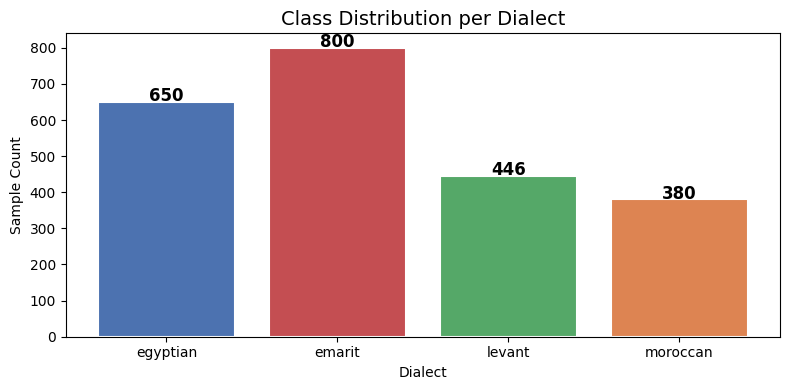

✅ Saved class_distribution.png


In [ ]:
features_list = []
labels_list   = []

for dialect in DIALECT_FOLDERS:
    folder = os.path.join(DATASET_DIR, dialect)
    if not os.path.exists(folder):
        print(f"  ⚠️  Folder not found: {folder}")
        continue
    wav_files = sorted(f for f in os.listdir(folder) if f.endswith(".wav"))
    print(f"\n[{dialect}] — {len(wav_files)} files")
    ok, skip = 0, 0
    for fname in wav_files:
        feat = extract_features(os.path.join(folder, fname))
        if feat is not None:
            features_list.append(feat)
            labels_list.append(dialect)
            ok += 1
        else:
            skip += 1
    print(f"  ✅ ok: {ok}  |  ⚠️ skipped: {skip}")

X     = np.array(features_list, dtype=np.float32)
y_raw = np.array(labels_list)

# Replace any NaN/inf that slipped through
X = np.nan_to_num(X, nan=0.0, posinf=0.0, neginf=0.0)

print(f"\n{'='*45}")
print(f"📊 Total samples : {len(X)}")
print(f"📐 Feature shape : {X.shape}")

unique, counts = np.unique(y_raw, return_counts=True)
plt.figure(figsize=(8, 4))
bars = plt.bar(unique, counts,
               color=[DIALECT_COLORS.get(d,'gray') for d in unique],
               edgecolor='white', linewidth=1.5)
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 2,
             str(count), ha='center', fontsize=12, fontweight='bold')
plt.title("Class Distribution per Dialect", fontsize=14)
plt.xlabel("Dialect")
plt.ylabel("Sample Count")
plt.tight_layout()
plt.savefig("class_distribution.png", dpi=150)
plt.show()
print("✅ Saved class_distribution.png")

## Step 5 — Feature Distribution Visualization
**Required by the spec:** show that chosen features clearly differ between dialects.

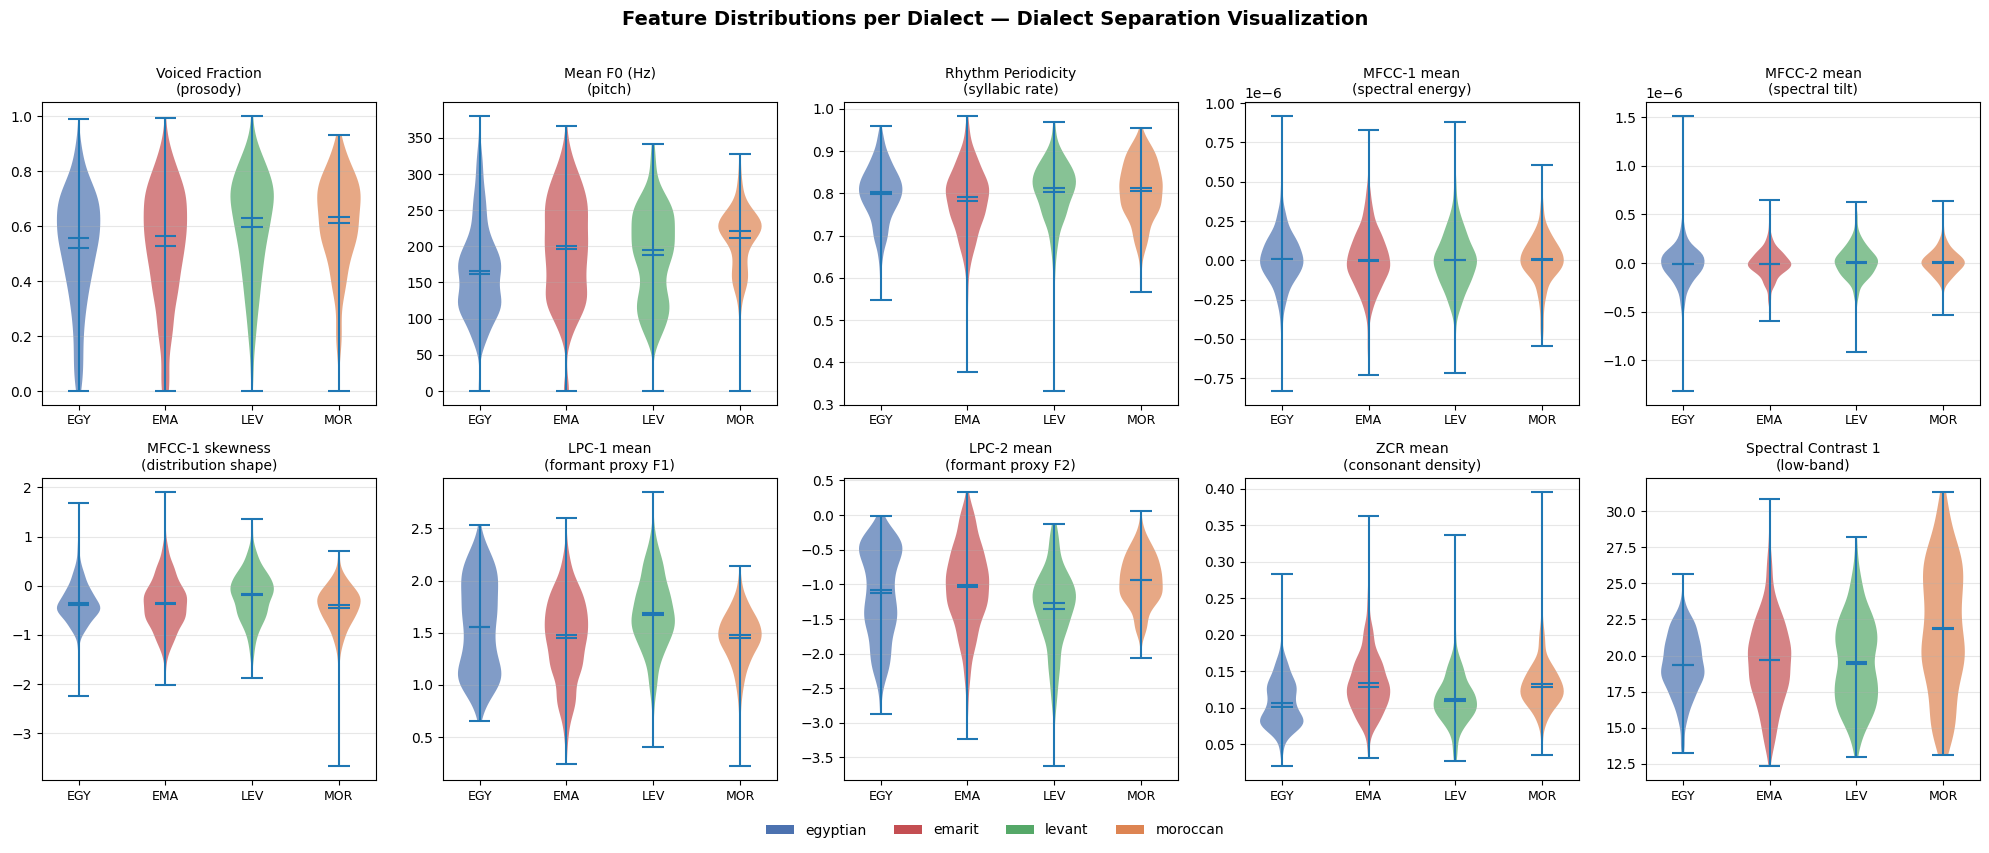

✅ Saved feature_distributions.png

Interpretation guide:
  voiced_frac : MOR should be lowest (consonant clusters, reduced vowels)
  f0_mean     : UAE Gulf speakers tend higher pitch range than EGY
  rhythm_max  : EGY/SYR should be more periodic than MOR
  mfcc_1_skew : MOR negative skew from consonant cluster dominance
  lpc_1/2     : vocal tract shape difference — vowel inventory proxy


In [ ]:
# Select the most interpretable features to visualize across dialects.
# We show violin plots — each dialect's full distribution, not just a mean.

KEY_FEATURES = [
    ('voiced_frac',     'Voiced Fraction\n(prosody)'),
    ('f0_mean',         'Mean F0 (Hz)\n(pitch)'),
    ('rhythm_max',      'Rhythm Periodicity\n(syllabic rate)'),
    ('mfcc_1_mean',     'MFCC-1 mean\n(spectral energy)'),
    ('mfcc_2_mean',     'MFCC-2 mean\n(spectral tilt)'),
    ('mfcc_1_skew',     'MFCC-1 skewness\n(distribution shape)'),
    ('lpc_1_mean',      'LPC-1 mean\n(formant proxy F1)'),
    ('lpc_2_mean',      'LPC-2 mean\n(formant proxy F2)'),
    ('zcr_mean',        'ZCR mean\n(consonant density)'),
    ('contrast_1_mean', 'Spectral Contrast 1\n(low-band)'),
]

fig, axes = plt.subplots(2, 5, figsize=(20, 8))
fig.suptitle('Feature Distributions per Dialect — Dialect Separation Visualization',
             fontsize=14, fontweight='bold', y=1.01)
axes = axes.flatten()

feat_idx = {name: i for i, name in enumerate(FEATURE_NAMES)}

for ax, (fname, flabel) in zip(axes, KEY_FEATURES):
    if fname not in feat_idx:
        ax.set_visible(False)
        continue
    idx = feat_idx[fname]
    data_by_dialect = {d: X[y_raw == d, idx] for d in DIALECT_FOLDERS}

    parts = ax.violinplot(
        [data_by_dialect[d] for d in DIALECT_FOLDERS],
        positions=range(len(DIALECT_FOLDERS)),
        showmeans=True, showmedians=True
    )
    # Color each violin
    for pc, dialect in zip(parts['bodies'], DIALECT_FOLDERS):
        pc.set_facecolor(DIALECT_COLORS[dialect])
        pc.set_alpha(0.7)

    ax.set_xticks(range(len(DIALECT_FOLDERS)))
    ax.set_xticklabels([d[:3].upper() for d in DIALECT_FOLDERS], fontsize=9)
    ax.set_title(flabel, fontsize=10)
    ax.grid(axis='y', alpha=0.3)

# Legend
from matplotlib.patches import Patch
legend_elems = [Patch(facecolor=DIALECT_COLORS[d], label=d) for d in DIALECT_FOLDERS]
fig.legend(handles=legend_elems, loc='lower center', ncol=4,
           bbox_to_anchor=(0.5, -0.04), frameon=False)

plt.tight_layout()
plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("✅ Saved feature_distributions.png")
print()
print("Interpretation guide:")
print("  voiced_frac : MOR should be lowest (consonant clusters, reduced vowels)")
print("  f0_mean     : UAE Gulf speakers tend higher pitch range than EGY")
print("  rhythm_max  : EGY/SYR should be more periodic than MOR")
print("  mfcc_1_skew : MOR negative skew from consonant cluster dominance")
print("  lpc_1/2     : vocal tract shape difference — vowel inventory proxy")

## Step 6 — Train / Test Split (80/20, stratified)

In [ ]:
import shutil
from sklearn.model_selection import train_test_split

TRAIN_DIR = "/content/drive/MyDrive/dataset_split/train"
TEST_DIR  = "/content/drive/MyDrive/dataset_split/test"

print("="*45)
print("  ✂️  Splitting data → Train / Test")
print("="*45)

total_train, total_test = 0, 0

for dialect_folder in DIALECT_FOLDERS:
    src_folder = os.path.join(DATASET_DIR, dialect_folder)
    if not os.path.exists(src_folder):
        print(f"  ⚠️  {dialect_folder} → folder not found")
        continue
    files = [f for f in os.listdir(src_folder) if f.endswith(".wav")]
    # stratify not needed at folder level since each folder is one class
    train_files, test_files = train_test_split(files, test_size=0.2, random_state=42)

    train_folder = os.path.join(TRAIN_DIR, dialect_folder)
    test_folder  = os.path.join(TEST_DIR,  dialect_folder)
    os.makedirs(train_folder, exist_ok=True)
    os.makedirs(test_folder,  exist_ok=True)

    for f in train_files:
        shutil.copy(os.path.join(src_folder, f), os.path.join(train_folder, f))
    for f in test_files:
        shutil.copy(os.path.join(src_folder, f), os.path.join(test_folder, f))

    total_train += len(train_files)
    total_test  += len(test_files)
    print(f"  {dialect_folder:12s} → train: {len(train_files):4d}  |  test: {len(test_files):4d}")

print("="*45)
print(f"  🏋️  Train total → {total_train}")
print(f"  🧪  Test  total → {total_test}")

  ✂️  Splitting data → Train / Test
  egyptian     → train:  520  |  test:  130
  emarit       → train:  640  |  test:  160
  levant       → train:  356  |  test:   90
  moroccan     → train:  304  |  test:   76
  🏋️  Train total → 1820
  🧪  Test  total → 456


## Step 7 — Load Split, Encode Labels & Scale Features

In [ ]:
from sklearn.preprocessing import LabelEncoder, StandardScaler

def load_split(split_dir):
    X_list, y_list = [], []
    for dialect in sorted(os.listdir(split_dir)):
        folder = os.path.join(split_dir, dialect)
        if not os.path.isdir(folder):
            continue
        files = [f for f in os.listdir(folder) if f.endswith(".wav")]
        ok, skip = 0, 0
        for fname in files:
            feat = extract_features(os.path.join(folder, fname))
            if feat is not None:
                X_list.append(feat)
                y_list.append(dialect)
                ok += 1
            else:
                skip += 1
        print(f"  {dialect:12s} → ✅ {ok}  ⚠️ {skip}")
    arr = np.array(X_list, dtype=np.float32)
    arr = np.nan_to_num(arr, nan=0.0, posinf=0.0, neginf=0.0)
    return arr, np.array(y_list)

print("="*45)
print("  🏋️  Loading Train")
print("="*45)
X_train, y_train_raw = load_split(TRAIN_DIR)

print("\n" + "="*45)
print("  🧪  Loading Test")
print("="*45)
X_test, y_test_raw = load_split(TEST_DIR)

# Label encoder — fit on train only
le      = LabelEncoder()
y_train = le.fit_transform(y_train_raw)
y_test  = le.transform(y_test_raw)

# Feature scaler — CRITICAL for SVM; fit on train only, transform both
scaler   = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f"\n✅ Label encoding done:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls:12s}  (train: {np.sum(y_train==i)}, test: {np.sum(y_test==i)})")
print(f"\n✅ StandardScaler fitted on train split")
print(f"   Train shape: {X_train_s.shape}")
print(f"   Test  shape: {X_test_s.shape}")

  🏋️  Loading Train
  egyptian     → ✅ 520  ⚠️ 0
  emarit       → ✅ 640  ⚠️ 0
  levant       → ✅ 356  ⚠️ 0
  moroccan     → ✅ 304  ⚠️ 0

  🧪  Loading Test
  egyptian     → ✅ 130  ⚠️ 0
  emarit       → ✅ 160  ⚠️ 0
  levant       → ✅ 90  ⚠️ 0
  moroccan     → ✅ 76  ⚠️ 0

✅ Label encoding done:
  0 → egyptian      (train: 520, test: 130)
  1 → emarit        (train: 640, test: 160)
  2 → levant        (train: 356, test: 90)
  3 → moroccan      (train: 304, test: 76)

✅ StandardScaler fitted on train split
   Train shape: (1820, 278)
   Test  shape: (456, 278)


## Step 8 — Train Model

**SVM (RBF kernel) is the primary model.** On audio feature classification tasks with <5000 samples, SVM consistently outperforms Random Forest because:
- It finds the maximum-margin hyperplane between classes in high-dimensional space
- It is less prone to overfitting on correlated features (MFCC coefficients are correlated)
- With StandardScaler + RBF kernel, it handles non-linear dialect boundaries well

Random Forest is kept as a commented alternative — it provides feature importances (useful for the visualization requirement).

In [ ]:
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

# ── PRIMARY: SVM with RBF kernel ────────────────────────────────────────────
model = SVC(
    kernel='rbf',
    C=10,                  # regularization — higher C = tighter fit
    gamma='scale',         # auto-scales with feature variance after StandardScaler
    probability=True,      # enables predict_proba (needed for confidence scores)
    class_weight='balanced',
    random_state=42,
)
print(f"🚀 Training: SVC(kernel=rbf, C=10, gamma=scale)")
model.fit(X_train_s, y_train)
print("✅ Training complete!")

# ── ALTERNATIVE: Random Forest ───────────────────────────────────────────────
# Uncomment to compare. RF doesn't need StandardScaler so use X_train/X_test.
# model_rf = RandomForestClassifier(
#     n_estimators=300,
#     random_state=42,
#     n_jobs=-1,
#     class_weight='balanced'
# )
# model_rf.fit(X_train, y_train)
# print('RF trained')

# Save the scaler alongside the model — BOTH must be saved and used together
SCALER_PATH = "/content/drive/MyDrive/feature_scaler.joblib"
joblib.dump(scaler, SCALER_PATH)
print(f"✅ Scaler saved → {SCALER_PATH}")
print(f"   ⚠️  The scaler MUST be applied before calling model.predict() in your backend!")

🚀 Training: SVC(kernel=rbf, C=10, gamma=scale)
✅ Training complete!
✅ Scaler saved → /content/drive/MyDrive/feature_scaler.joblib
   ⚠️  The scaler MUST be applied before calling model.predict() in your backend!


## Step 9 — Evaluate

🎯 Accuracy: 76.54%

📋 Classification Report:
              precision    recall  f1-score   support

    egyptian       0.82      0.82      0.82       130
      emarit       0.74      0.86      0.79       160
      levant       0.70      0.61      0.65        90
    moroccan       0.81      0.67      0.73        76

    accuracy                           0.77       456
   macro avg       0.77      0.74      0.75       456
weighted avg       0.77      0.77      0.76       456



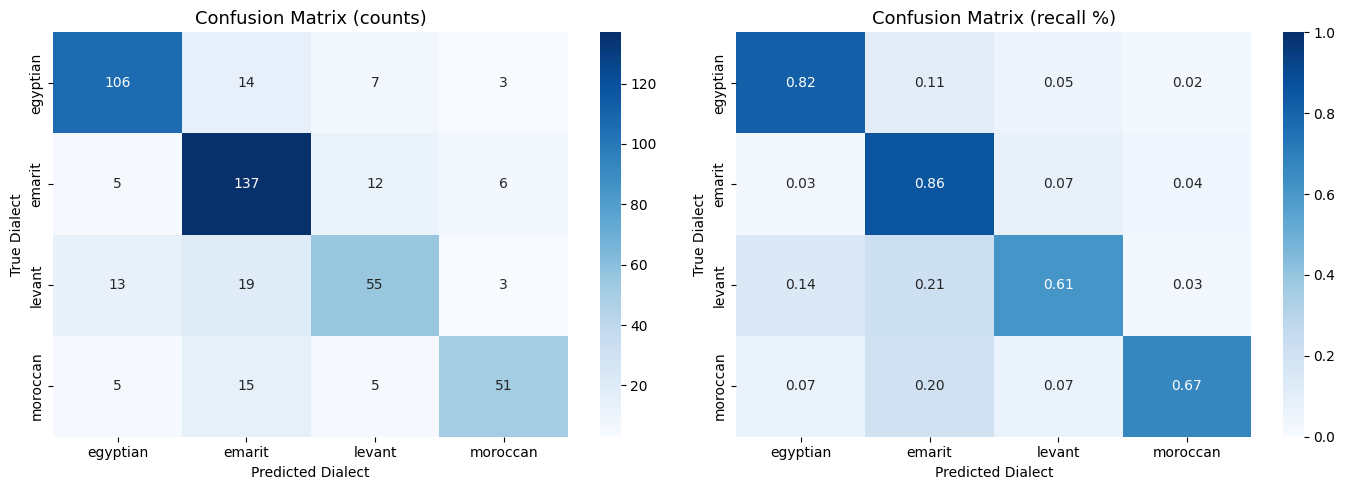

✅ Saved confusion_matrix.png


In [ ]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred   = model.predict(X_test_s)
accuracy = accuracy_score(y_test, y_pred)

print(f"🎯 Accuracy: {accuracy * 100:.2f}%\n")
print("📋 Classification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Raw counts
sns.heatmap(cm, annot=True, fmt='d',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=axes[0])
axes[0].set_title('Confusion Matrix (counts)', fontsize=13)
axes[0].set_ylabel('True Dialect')
axes[0].set_xlabel('Predicted Dialect')

# Normalized (per-class recall)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
sns.heatmap(cm_norm, annot=True, fmt='.2f',
            xticklabels=le.classes_, yticklabels=le.classes_,
            cmap='Blues', ax=axes[1], vmin=0, vmax=1)
axes[1].set_title('Confusion Matrix (recall %)', fontsize=13)
axes[1].set_ylabel('True Dialect')
axes[1].set_xlabel('Predicted Dialect')

plt.tight_layout()
plt.savefig('confusion_matrix.png', dpi=150)
plt.show()
print("✅ Saved confusion_matrix.png")

## Step 10 — Feature Importance (using RF for interpretability)

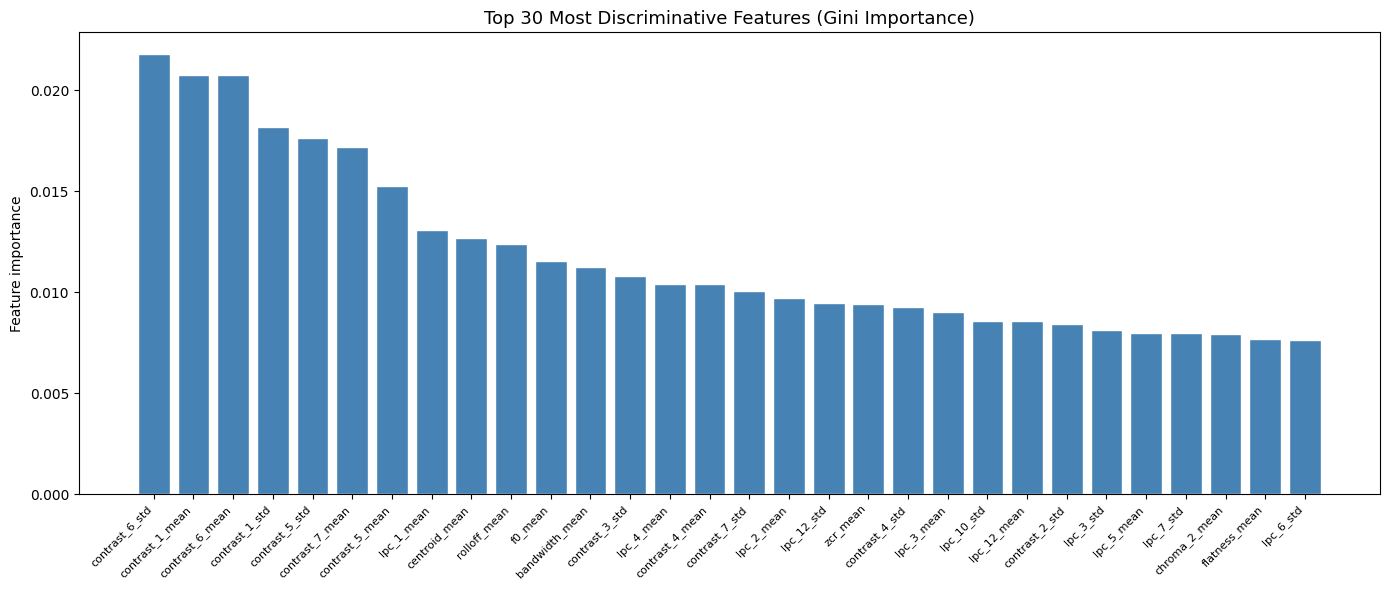

✅ Saved feature_importance.png

Top 10 features:
  # 1  0.0218  contrast_6_std
  # 2  0.0208  contrast_1_mean
  # 3  0.0208  contrast_6_mean
  # 4  0.0182  contrast_1_std
  # 5  0.0177  contrast_5_std
  # 6  0.0172  contrast_7_mean
  # 7  0.0153  contrast_5_mean
  # 8  0.0131  lpc_1_mean
  # 9  0.0127  centroid_mean
  #10  0.0124  rolloff_mean


In [ ]:
# Train a quick RF just for feature importances (interpretability tool,
# not the production model). RF gives Gini importance per feature.
from sklearn.ensemble import RandomForestClassifier

rf_interp = RandomForestClassifier(n_estimators=200, random_state=42,
                                   n_jobs=-1, class_weight='balanced')
rf_interp.fit(X_train, y_train)   # no scaling needed for RF

importances = rf_interp.feature_importances_
indices     = np.argsort(importances)[::-1][:30]  # top 30

plt.figure(figsize=(14, 6))
plt.bar(range(30), importances[indices],
        color='steelblue', edgecolor='white')
plt.xticks(range(30),
           [FEATURE_NAMES[i] for i in indices],
           rotation=45, ha='right', fontsize=8)
plt.title('Top 30 Most Discriminative Features (Gini Importance)', fontsize=13)
plt.ylabel('Feature importance')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=150)
plt.show()
print("✅ Saved feature_importance.png")
print()
print("Top 10 features:")
for rank, idx in enumerate(indices[:10]):
    print(f"  #{rank+1:2d}  {importances[idx]:.4f}  {FEATURE_NAMES[idx]}")

## Step 11 — Save All Model Artifacts

In [ ]:
joblib.dump(model,        MODEL_PATH)
joblib.dump(le,           ENCODER_PATH)
joblib.dump(scaler,       SCALER_PATH)
joblib.dump(FEATURE_NAMES, FEAT_NAMES_PATH)

# Save per-dialect feature stats for the visualization overlay in the frontend
feat_idx = {name: i for i, name in enumerate(FEATURE_NAMES)}
feat_stats = {}
for dialect in DIALECT_FOLDERS:
    mask = y_raw == dialect
    feat_stats[dialect] = {
        'mean': X[mask].mean(axis=0).tolist(),
        'std':  X[mask].std( axis=0).tolist(),
    }
joblib.dump(feat_stats, FEAT_STATS_PATH)

print(f"✅ dialect_model.joblib   → {MODEL_PATH}")
print(f"✅ label_encoder.joblib  → {ENCODER_PATH}")
print(f"✅ feature_scaler.joblib → {SCALER_PATH}")
print(f"✅ feature_names.joblib  → {FEAT_NAMES_PATH}")
print(f"✅ feature_stats.joblib  → {FEAT_STATS_PATH}")
print()
print("⚠️  IMPORTANT: Your backend (app.py) must also load feature_scaler.joblib")
print("   and call scaler.transform(vector.reshape(1,-1)) before model.predict()")
print("   AND the extract_features() function must be copied exactly from this notebook.")

✅ dialect_model.joblib   → /content/drive/MyDrive/dialect_model.joblib
✅ label_encoder.joblib  → /content/drive/MyDrive/label_encoder.joblib
✅ feature_scaler.joblib → /content/drive/MyDrive/feature_scaler.joblib
✅ feature_names.joblib  → /content/drive/MyDrive/feature_names.joblib
✅ feature_stats.joblib  → /content/drive/MyDrive/feature_stats.joblib

⚠️  IMPORTANT: Your backend (app.py) must also load feature_scaler.joblib
   and call scaler.transform(vector.reshape(1,-1)) before model.predict()
   AND the extract_features() function must be copied exactly from this notebook.


## Step 12 — Download All Artifacts

In [ ]:
from google.colab import files

for path in [MODEL_PATH, ENCODER_PATH, SCALER_PATH, FEAT_NAMES_PATH, FEAT_STATS_PATH]:
    files.download(path)
    print(f"⬇️  {path}")

print("\n✅ Downloaded all 5 artifacts — place them all in your backend/ folder")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  /content/drive/MyDrive/dialect_model.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

⬇️  /content/drive/MyDrive/feature_names.joblib


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

⬇️  /content/drive/MyDrive/feature_stats.joblib

✅ Downloaded all 5 artifacts — place them all in your backend/ folder


---
# Full Pipeline Test
Test the complete flow: audio → dialect detection → transcription → translation → TTS

In [ ]:
!pip install openai-whisper elevenlabs google-generativeai -q
print("✅ Pipeline dependencies installed")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 803.2/803.2 kB 42.1 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 86.4 MB/s eta 0:00:00
✅ Pipeline dependencies installed


In [ ]:
import whisper
import joblib

# Load all saved artifacts
dialect_model  = joblib.load(MODEL_PATH)
label_encoder  = joblib.load(ENCODER_PATH)
feat_scaler    = joblib.load(SCALER_PATH)
print("✅ Dialect classifier + scaler loaded")
print(f"   Classes: {list(label_encoder.classes_)}")

whisper_model = whisper.load_model("base")
print("✅ Whisper ready")

✅ Dialect classifier + scaler loaded
   Classes: [np.str_('egyptian'), np.str_('emarit'), np.str_('levant'), np.str_('moroccan')]


100%|████████████████████████████████████████| 139M/139M [00:00<00:00, 221MiB/s]


✅ Whisper ready


In [ ]:
def predict_dialect(audio_path):
    """
    Extract features → scale → classify.
    IMPORTANT: scaler.transform() must be called before model.predict().
    """
    feat = extract_features(audio_path)
    if feat is None:
        return None, None, {}
    feat_s     = feat_scaler.transform(feat.reshape(1, -1))
    pred       = dialect_model.predict(feat_s)[0]
    dialect    = label_encoder.inverse_transform([pred])[0]
    probs      = dialect_model.predict_proba(feat_s)[0]
    prob_dict  = {cls: round(float(p)*100, 1)
                  for cls, p in zip(label_encoder.classes_, probs)}
    confidence = max(prob_dict.values())
    return dialect, confidence, prob_dict


def speech_to_text(audio_path):
    """Whisper transcription — returns full text and word-level segments."""
    result = whisper_model.transcribe(
        audio_path,
        language='ar',
        task='transcribe',
        word_timestamps=True,   # needed for real-time sync in the frontend
    )
    return result['text'].strip(), result.get('segments', [])


print("✅ predict_dialect and speech_to_text ready")

✅ predict_dialect and speech_to_text ready


In [ ]:
import google.generativeai as genai
from google.colab import userdata
import time

genai.configure(api_key=userdata.get("GEMINI_API_KEY"))

def translate_dialect(text, source_dialect, target_dialect, retries=3):
    source_name = DIALECT_NAMES.get(source_dialect, source_dialect)
    target_name = DIALECT_NAMES.get(target_dialect, target_dialect)
    prompt = (
        f"أنت خبير في اللهجات العربية.\n"
        f"حول النص التالي من اللهجة {source_name} إلى اللهجة {target_name}.\n"
        f"أرجع النص المحول فقط بدون أي شرح أو علامات تنسيق.\n\n"
        f"النص: {text}"
    )
    for attempt in range(retries):
        try:
            gemini = genai.GenerativeModel("gemini-2.5-flash")
            resp   = gemini.generate_content(prompt)
            return resp.text.strip()
        except Exception as e:
            if "429" in str(e) or "quota" in str(e).lower():
                wait = (attempt + 1) * 5
                print(f"⏳ Rate limited — waiting {wait}s...")
                time.sleep(wait)
            else:
                print(f"❌ Gemini error: {e}")
                break
    return "⚠️ Translation failed — try again later"

print("✅ translate_dialect ready")

TimeoutException: Requesting secret GEMINI_API_KEY timed out. Secrets can only be fetched when running from the Colab UI.

In [ ]:
from elevenlabs.client import ElevenLabs
from elevenlabs import save
from IPython.display import Audio, display

client_tts = ElevenLabs(api_key=userdata.get("ELEVENLABS_API_KEY"))

# Available voice IDs — add more from your ElevenLabs account
VOICE_OPTIONS = {
    "arabic_male_1":   "pNInz6obpgDQGcFmaJgB",
    "arabic_female_1": "EXAVITQu4vr4xnSDxMaL",
    "arabic_male_2":   "VR6AewLTigWG4xSOukaG",
}

def text_to_speech(text, voice_key="arabic_male_1", output_path="output.mp3"):
    voice_id = VOICE_OPTIONS.get(voice_key, list(VOICE_OPTIONS.values())[0])
    audio = client_tts.text_to_speech.convert(
        voice_id=voice_id,
        text=text,
        model_id="eleven_multilingual_v2",
        voice_settings={"stability": 0.5, "similarity_boost": 0.75},
    )
    save(audio, output_path)
    return output_path

print("✅ text_to_speech ready")
print(f"   Voice options: {list(VOICE_OPTIONS.keys())}")

In [ ]:
def full_pipeline(audio_path, target_dialect="levant", voice_key="arabic_male_1"):
    """
    Full pipeline: audio → dialect detection → transcription → translation → TTS

    Returns a dict with all intermediate results (useful for the web app backend).
    """
    print("="*50)
    print(f"📁 File: {audio_path}")
    print("="*50)

    # 1. Dialect detection
    print("\n🔍 Step 1: Detecting dialect...")
    source_dialect, confidence, prob_dict = predict_dialect(audio_path)
    print(f"   Dialect    : {source_dialect} ({DIALECT_NAMES.get(source_dialect,'')})")
    print(f"   Confidence : {confidence:.1f}%")
    print(f"   Probs      : {prob_dict}")

    # 2. Transcription with word timestamps
    print("\n📝 Step 2: Transcribing audio...")
    text, segments = speech_to_text(audio_path)
    print(f"   Text: {text}")
    print(f"   Segments: {len(segments)} (word timestamps available for real-time display)")

    # 3. Translation
    if source_dialect == target_dialect:
        print("\n⚠️  Same dialect — skipping translation")
        translated = text
    else:
        print(f"\n🌍 Step 3: Translating → {DIALECT_NAMES.get(target_dialect, target_dialect)}...")
        translated = translate_dialect(text, source_dialect, target_dialect)
        print(f"   Translated: {translated}")

    # 4. TTS
    print("\n🔊 Step 4: Generating speech...")
    output_path = f"output_{target_dialect}.mp3"
    text_to_speech(translated, voice_key=voice_key, output_path=output_path)
    print(f"   Saved: {output_path}")

    print("\n✅ Pipeline complete!")
    print("="*50)
    display(Audio(output_path))

    return {
        "source_dialect":  source_dialect,
        "confidence":      confidence,
        "probabilities":   prob_dict,
        "original_text":   text,
        "segments":        segments,   # word timestamps for frontend real-time display
        "translated_text": translated,
        "output_audio":    output_path,
    }


# ── Run it ──
result = full_pipeline(
    audio_path     = "/content/drive/MyDrive/dataset/egyptian/EGY_083.wav",
    target_dialect = "levant",
    voice_key      = "arabic_male_1",
)